In [4]:
# =============================================================================
# CHAPITRE 5 – MODÉLISATION PRÉDICTIVE DU SCORE ESG (VERSION CORRIGÉE)
# =============================================================================
# Ce code implémente une comparaison complète de modèles pour prédire le score ESG.
# Respect du split temporel (train 2018-2019, test 2020),
# TimeSeriesSplit pour le tuning, métriques avec bootstrap, visualisations.
# Optuna n'est pas disponible → utilisation de RandomizedSearchCV.
# =============================================================================

import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_rel, wilcoxon
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import TargetEncoder
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import xgboost as xgb
import lightgbm as lgb
import catboost as cb
import shap

warnings.filterwarnings('ignore')

# Configuration
RANDOM_STATE = 42
N_BOOTSTRAP = 1000
TEST_YEAR = 2020
TRAIN_YEARS = [2018, 2019]
os.makedirs("figures", exist_ok=True)
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style="whitegrid")

In [2]:
# =============================================================================
# 1. CHARGEMENT ET PRÉPARATION DES DONNÉES
# =============================================================================
df = pd.read_pickle("df_ready_for_ML.pkl")
if 'year' in df.index.names:
    df = df.reset_index()
assert 'year' in df.columns, "La colonne 'year' est introuvable."

target = 'esg_score_v3'
features_quant = [c for c in df.columns if c not in 
                  ['company_id', 'year', 'primary_industry', 'company_name', 'ticker',
                   'hq_country', target, 'score_E', 'score_S', 'score_G']]
print(f"Nombre de features quantitatives : {len(features_quant)}")

train_df = df[df['year'].isin(TRAIN_YEARS)].copy()
test_df = df[df['year'] == TEST_YEAR].copy()
print(f"Train : {train_df.shape} (années {train_df['year'].unique()})")
print(f"Test  : {test_df.shape} (année {test_df['year'].unique()})")

assert train_df[target].notna().all() and test_df[target].notna().all()

Nombre de features quantitatives : 22
Train : (27036, 31) (années [2018 2019])
Test  : (13518, 31) (année [2020])


In [3]:
# =============================================================================
# 2. TARGET ENCODING AVEC CROSS-VALIDATION INTERNE
# =============================================================================
target_encoder = TargetEncoder(cv=5, smooth='auto', random_state=RANDOM_STATE)
industry_train_enc = target_encoder.fit_transform(train_df[['primary_industry']], train_df[target])
industry_test_enc = target_encoder.transform(test_df[['primary_industry']])
industry_train_enc = pd.Series(industry_train_enc.ravel(), index=train_df.index, name='industry_target_enc')
industry_test_enc = pd.Series(industry_test_enc.ravel(), index=test_df.index, name='industry_target_enc')

X_train_quant = train_df[features_quant].copy()
X_test_quant = test_df[features_quant].copy()
train_means = X_train_quant.mean()
test_means = X_test_quant.mean()
print(f"\nVérification des échelles : écart maximal de moyenne = {(train_means - test_means).abs().max()}")

X_train = pd.concat([X_train_quant, industry_train_enc], axis=1)
X_test = pd.concat([X_test_quant, industry_test_enc], axis=1)
y_train = train_df[target].values
y_test = test_df[target].values
print(f"Shape X_train : {X_train.shape}, X_test : {X_test.shape}")


Vérification des échelles : écart maximal de moyenne = 0.49902426355880497
Shape X_train : (27036, 23), X_test : (13518, 23)


In [4]:
# =============================================================================
# 3. DÉFINITION DES MODÈLES ET DES DISTRIBUTIONS D'HYPERPARAMÈTRES
# =============================================================================
tscv = TimeSeriesSplit(n_splits=3)

# Pour l'early stopping final, on réserve une validation
split_idx = int(0.8 * len(X_train))
X_val = X_train.iloc[split_idx:]
y_val = y_train[split_idx:]

models_config = {}

# 3.1 Régression Linéaire
models_config['LinearRegression'] = {
    'model': LinearRegression(),
    'param_dist': None
}

# 3.2 ElasticNet
models_config['ElasticNet'] = {
    'model': ElasticNet(random_state=RANDOM_STATE, max_iter=5000),
    'param_dist': {
        'alpha': list(np.logspace(-4, 2, 20)),
        'l1_ratio': [0.1, 0.5, 0.7, 0.9, 1.0]
    }
}

# 3.3 Decision Tree
models_config['DecisionTree'] = {
    'model': DecisionTreeRegressor(random_state=RANDOM_STATE),
    'param_dist': {
        'max_depth': [5, 10, 20, None],
        'min_samples_split': [2, 5, 10, 20],
        'min_samples_leaf': [1, 2, 4]
    }
}

# 3.4 SVR
models_config['SVR'] = {
    'model': SVR(kernel='rbf'),
    'param_dist': {
        'C': list(np.logspace(-2, 3, 15)),
        'epsilon': list(np.linspace(0.01, 1, 8)),
        'gamma': list(np.logspace(-4, 1, 12))
    }
}

# 3.5 Random Forest
models_config['RandomForest'] = {
    'model': RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    'param_dist': {
        'n_estimators': [100, 200, 300, 500],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10, 20],
        'min_samples_leaf': [1, 2, 4]
    }
}

# 3.6 XGBoost – on désactive early stopping pendant la recherche
models_config['XGBoost'] = {
    'model': xgb.XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, early_stopping_rounds=None),
    'param_dist': {
        'n_estimators': [100, 200, 300, 500],
        'max_depth': [3, 5, 7, 9],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
        'reg_alpha': [0, 0.1, 1, 10],
        'reg_lambda': [0.5, 1, 1.5, 2]
    },
    'early_stopping': True,      # pour l'entraînement final
    'eval_set': [(X_val, y_val)]
}

# 3.7 LightGBM – désactiver early stopping pendant recherche
models_config['LightGBM'] = {
    'model': lgb.LGBMRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1, early_stopping_rounds=None),
    'param_dist': {
        'num_leaves': [31, 50, 100],
        'learning_rate': [0.01, 0.05, 0.1],
        'n_estimators': [100, 300, 500],
        'feature_fraction': [0.6, 0.8, 1.0],
        'bagging_fraction': [0.6, 0.8, 1.0]
    },
    'early_stopping': True,
    'eval_set': [(X_val, y_val)]
}

# 3.8 CatBoost – désactiver early stopping pendant recherche
models_config['CatBoost'] = {
    'model': cb.CatBoostRegressor(random_seed=RANDOM_STATE, verbose=False, early_stopping_rounds=None),
    'param_dist': {
        'iterations': [100, 300, 500],
        'learning_rate': [0.01, 0.05, 0.1],
        'depth': [4, 6, 8]
    },
    'early_stopping': True,
    'eval_set': [(X_val, y_val)]
}


In [5]:
# =============================================================================
# 4. FONCTION D'OPTIMISATION (RANDOMIZED SEARCH)
# =============================================================================
def optimize_randomsearch(model, param_dist, X_tr, y_tr, cv, n_iter=50):
    """Recherche aléatoire avec validation croisée."""
    search = RandomizedSearchCV(model, param_dist, n_iter=n_iter, cv=cv,
                                scoring='neg_mean_squared_error', n_jobs=-1,
                                random_state=RANDOM_STATE, verbose=0)
    search.fit(X_tr, y_tr)
    return search.best_params_

In [19]:
# =============================================================================
# 5. ENTRAÎNEMENT ET ÉVALUATION
# =============================================================================
results = []
predictions = {}
models = {}
training_times = {}

for name, config in models_config.items():
    print(f"\n--- Optimisation de {name} ---")
    start_time = time.time()
    model = config['model']
    param_dist = config.get('param_dist')
    
    if param_dist is not None:
        best_params = optimize_randomsearch(model, param_dist, X_train, y_train, tscv, n_iter=50)
        model.set_params(**best_params)
        print(f"Meilleurs paramètres : {best_params}")
    else:
        print("Aucun paramètre à optimiser.")
    
    # Entraînement final (avec early stopping si configuré)
    early_stop = config.get('early_stopping', False)
    eval_set = config.get('eval_set', None)
    
    if early_stop and eval_set is not None:
        if name == 'XGBoost':
            # Réactiver early stopping
            model.set_params(early_stopping_rounds=50, eval_metric='rmse')
            model.fit(X_train, y_train, eval_set=eval_set, verbose=False)
        elif name == 'LightGBM':
            model.fit(X_train, y_train, eval_set=eval_set, 
                      callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)])
        elif name == 'CatBoost':
            model.fit(X_train, y_train, eval_set=eval_set, verbose=False, early_stopping_rounds=50)
        else:
            model.fit(X_train, y_train)
    else:
        model.fit(X_train, y_train)
    
    training_times[name] = time.time() - start_time
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    predictions[name] = y_test_pred
    models[name] = model
    
    # Métriques
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_mape = mean_absolute_percentage_error(y_test, y_test_pred) * 100
    test_medae = np.median(np.abs(y_test - y_test_pred))
    
    # Bootstrap
    n_test = len(y_test)
    boot_rmse, boot_mae, boot_r2 = [], [], []
    for _ in range(N_BOOTSTRAP):
        idx = np.random.choice(n_test, n_test, replace=True)
        y_true_b = y_test[idx]
        y_pred_b = y_test_pred[idx]
        boot_rmse.append(np.sqrt(mean_squared_error(y_true_b, y_pred_b)))
        boot_mae.append(mean_absolute_error(y_true_b, y_pred_b))
        boot_r2.append(r2_score(y_true_b, y_pred_b))
    
    results.append({
        'Modèle': name,
        'R²_train': train_r2,
        'R²_test': test_r2,
        'RMSE_test': test_rmse,
        'RMSE_std': np.std(boot_rmse),
        'MAE_test': test_mae,
        'MAE_std': np.std(boot_mae),
        'MAPE_test': test_mape,
        'MedAE_test': test_medae,
        'Temps(s)': training_times[name],
        'Overfitting (R² diff)': train_r2 - test_r2
    })


--- Optimisation de LinearRegression ---
Aucun paramètre à optimiser.

--- Optimisation de ElasticNet ---
Meilleurs paramètres : {'l1_ratio': 1.0, 'alpha': np.float64(0.007847599703514606)}

--- Optimisation de DecisionTree ---
Meilleurs paramètres : {'min_samples_split': 20, 'min_samples_leaf': 4, 'max_depth': 10}

--- Optimisation de SVR ---
Meilleurs paramètres : {'gamma': np.float64(0.006579332246575682), 'epsilon': np.float64(0.4342857142857143), 'C': np.float64(193.06977288832496)}

--- Optimisation de RandomForest ---
Meilleurs paramètres : {'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_depth': 20}

--- Optimisation de XGBoost ---
Meilleurs paramètres : {'subsample': 0.8, 'reg_lambda': 2, 'reg_alpha': 0.1, 'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 1.0}

--- Optimisation de LightGBM ---
Meilleurs paramètres : {'num_leaves': 31, 'n_estimators': 300, 'learning_rate': 0.05, 'feature_fraction': 0.6, 'bagging_fraction'

In [6]:
# =============================================================================
# 5.5 SAUVEGARDE DES MODÈLES ET DES PRÉDICTIONS (AJOUT)
# =============================================================================
import joblib
import pickle

# Créer un dossier pour les modèles sauvegardés
os.makedirs("saved_models", exist_ok=True)

# Sauvegarde de chaque modèle entraîné
for name, model in models.items():
    joblib.dump(model, f"saved_models/{name}.pkl")
    print(f"Modèle {name} sauvegardé dans saved_models/{name}.pkl")

# Sauvegarde des prédictions et métriques
with open("saved_models/predictions.pkl", "wb") as f:
    pickle.dump(predictions, f)

with open("saved_models/results.pkl", "wb") as f:
    pickle.dump(results, f)

# Sauvegarde des données de test (nécessaires pour les graphiques)
with open("saved_models/y_test.pkl", "wb") as f:
    pickle.dump(y_test, f)

with open("saved_models/X_test.pkl", "wb") as f:
    pickle.dump(X_test, f)

print("\n✅ Tous les modèles et données ont été sauvegardés.")

NameError: name 'models' is not defined

In [7]:
# =============================================================================
# CHARGEMENT DES MODÈLES SAUVEGARDÉS (EXÉCUTION RAPIDE)
# =============================================================================
import joblib
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Chargement des modèles
models = {}
model_names = ['LinearRegression', 'ElasticNet', 'DecisionTree', 'SVR', 
               'RandomForest', 'XGBoost', 'LightGBM', 'CatBoost']

for name in model_names:
    try:
        models[name] = joblib.load(f"saved_models/{name}.pkl")
        print(f"✅ {name} chargé")
    except FileNotFoundError:
        print(f"❌ {name} non trouvé")

# Chargement des prédictions et données
with open("saved_models/predictions.pkl", "rb") as f:
    predictions = pickle.load(f)

with open("saved_models/results.pkl", "rb") as f:
    results = pickle.load(f)

with open("saved_models/y_test.pkl", "rb") as f:
    y_test = pickle.load(f)

with open("saved_models/X_test.pkl", "rb") as f:
    X_test = pickle.load(f)

print("\n✅ Toutes les données sont chargées. Prêt pour les graphiques supplémentaires.")

✅ LinearRegression chargé
✅ ElasticNet chargé
✅ DecisionTree chargé
✅ SVR chargé
✅ RandomForest chargé
✅ XGBoost chargé
✅ LightGBM chargé
✅ CatBoost chargé

✅ Toutes les données sont chargées. Prêt pour les graphiques supplémentaires.


In [8]:
# =============================================================================
# 6. TABLEAU COMPARATIF ET TEST STATISTIQUE
# =============================================================================
results_df = pd.DataFrame(results).sort_values('R²_test', ascending=False)
print("\n" + "="*80)
print("TABLEAU COMPARATIF DES PERFORMANCES")
print("="*80)
print(results_df.round(4).to_string())
results_df.to_csv("model_comparison.csv", index=False)

best_models = results_df.head(2)['Modèle'].values
print(f"\nMeilleurs modèles : {best_models[0]} et {best_models[1]}")
if len(best_models) == 2:
    errors1 = np.abs(y_test - predictions[best_models[0]])
    errors2 = np.abs(y_test - predictions[best_models[1]])
    # Test de normalité sur un échantillon réduit
    _, p_norm1 = stats.shapiro(errors1[:5000])
    _, p_norm2 = stats.shapiro(errors2[:5000])
    if p_norm1 > 0.05 and p_norm2 > 0.05:
        t_stat, p_value = ttest_rel(errors1, errors2)
        test_name = "t-test apparié"
    else:
        t_stat, p_value = wilcoxon(errors1, errors2)
        test_name = "Wilcoxon"
    print(f"\n{test_name} entre les erreurs absolues : p-value = {p_value:.6f}")
    if p_value < 0.05:
        print(f"→ {best_models[0]} est significativement meilleur.")
    else:
        print("→ Pas de différence significative.")



TABLEAU COMPARATIF DES PERFORMANCES
             Modèle  R²_train  R²_test  RMSE_test  RMSE_std  MAE_test  MAE_std     MAPE_test  MedAE_test   Temps(s)  Overfitting (R² diff)
7          CatBoost    0.9618   0.9532     6.6546    0.0756    4.9499   0.0385  4.545806e+14      3.7779   186.5667                 0.0086
6          LightGBM    0.9623   0.9497     6.8999    0.0746    5.0897   0.0393  2.553508e+14      3.8393   164.5290                 0.0127
5           XGBoost    0.9650   0.9496     6.9035    0.0755    5.1013   0.0400  3.445410e+14      3.8591   129.6883                 0.0154
4      RandomForest    0.9831   0.9407     7.4900    0.0814    5.3917   0.0452  7.599309e+14      3.9406  2541.4974                 0.0424
3               SVR    0.9420   0.9385     7.6288    0.0763    5.5371   0.0461  1.032350e+15      4.0303  4277.4336                 0.0035
2      DecisionTree    0.9521   0.9053     9.4626    0.0952    6.6967   0.0577  6.042835e+14      4.7469    23.0034              

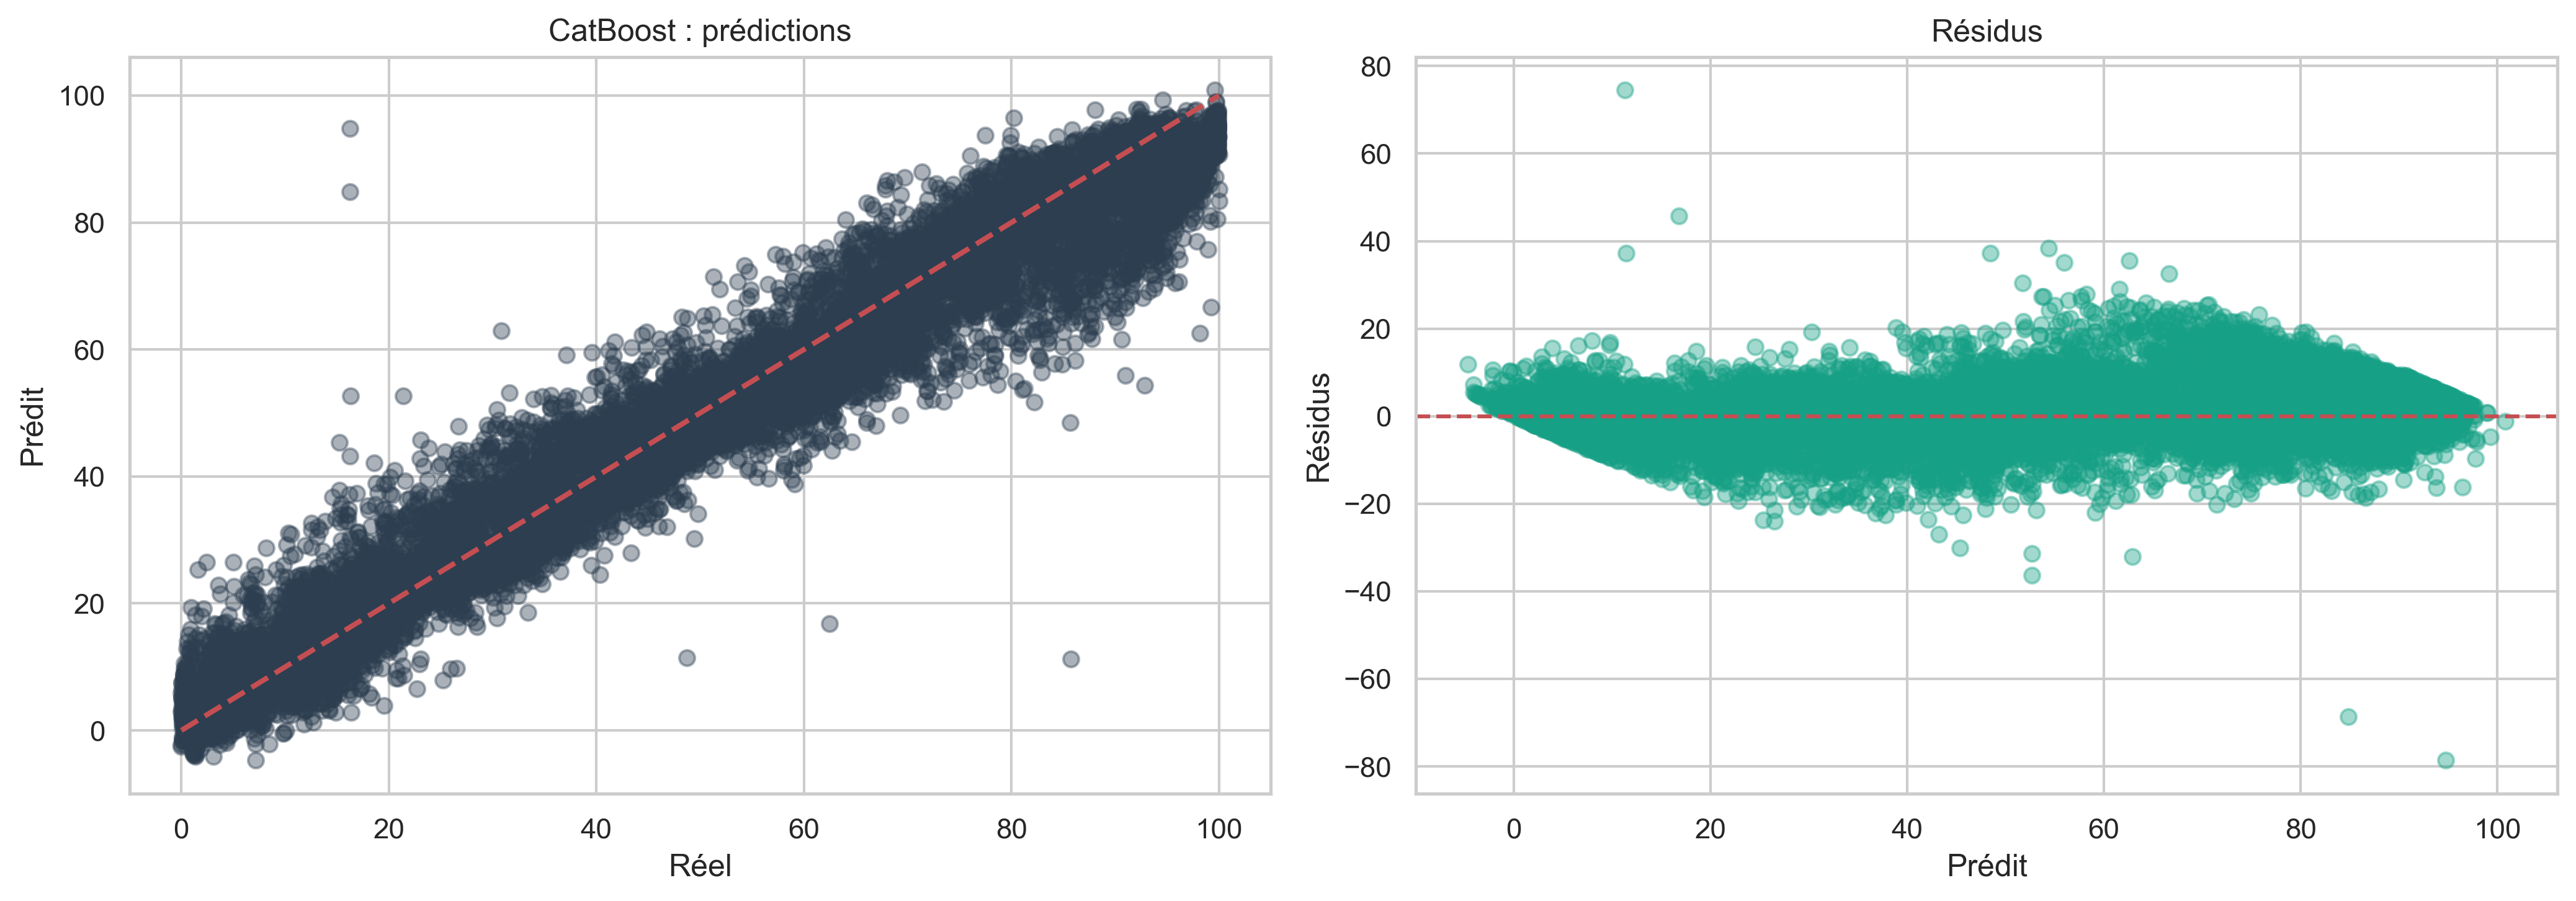

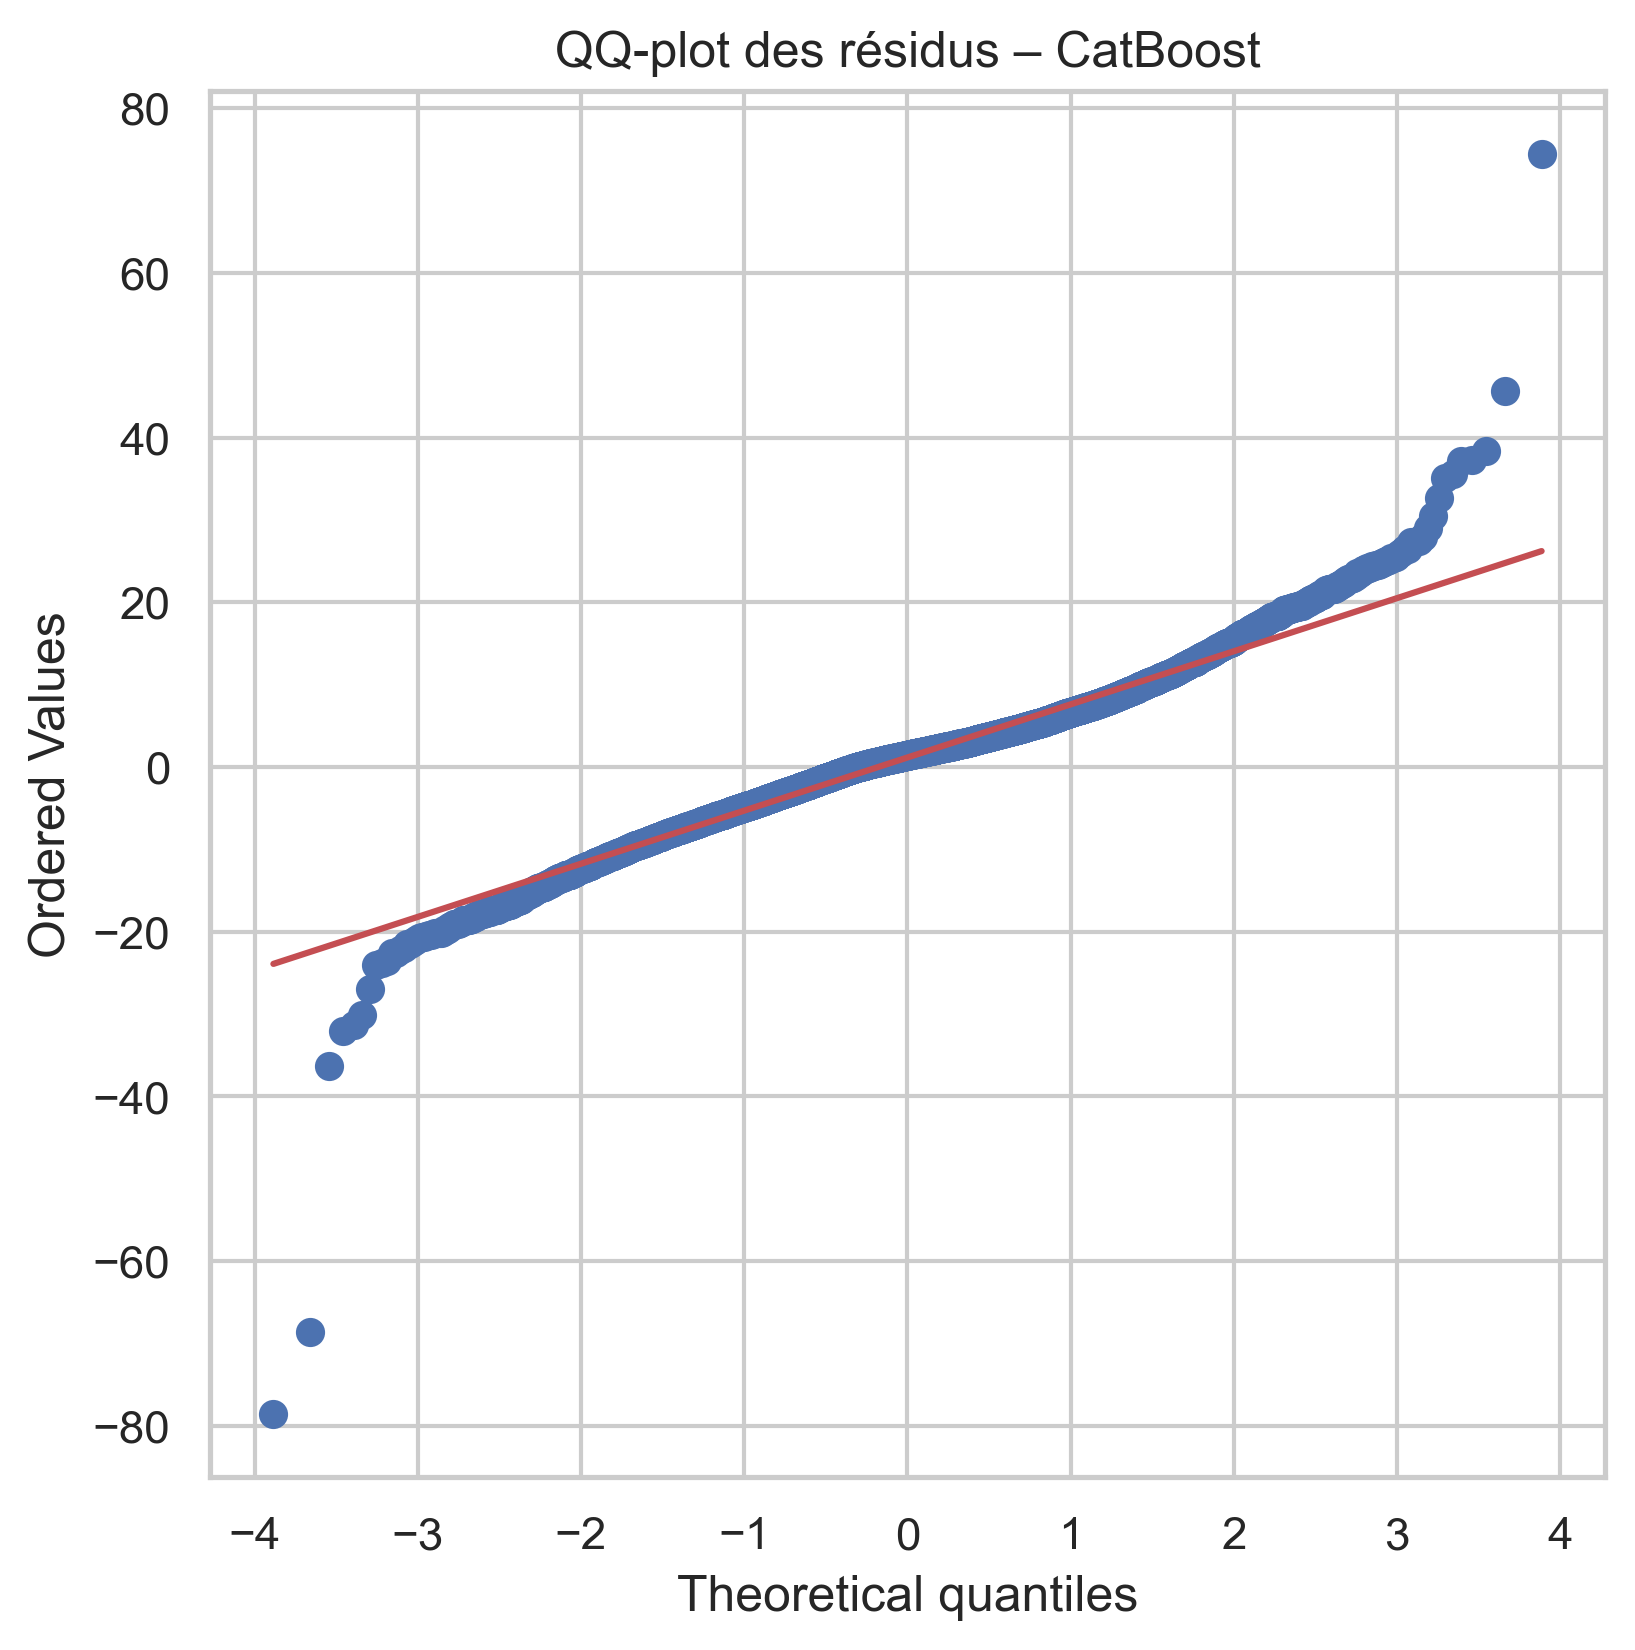

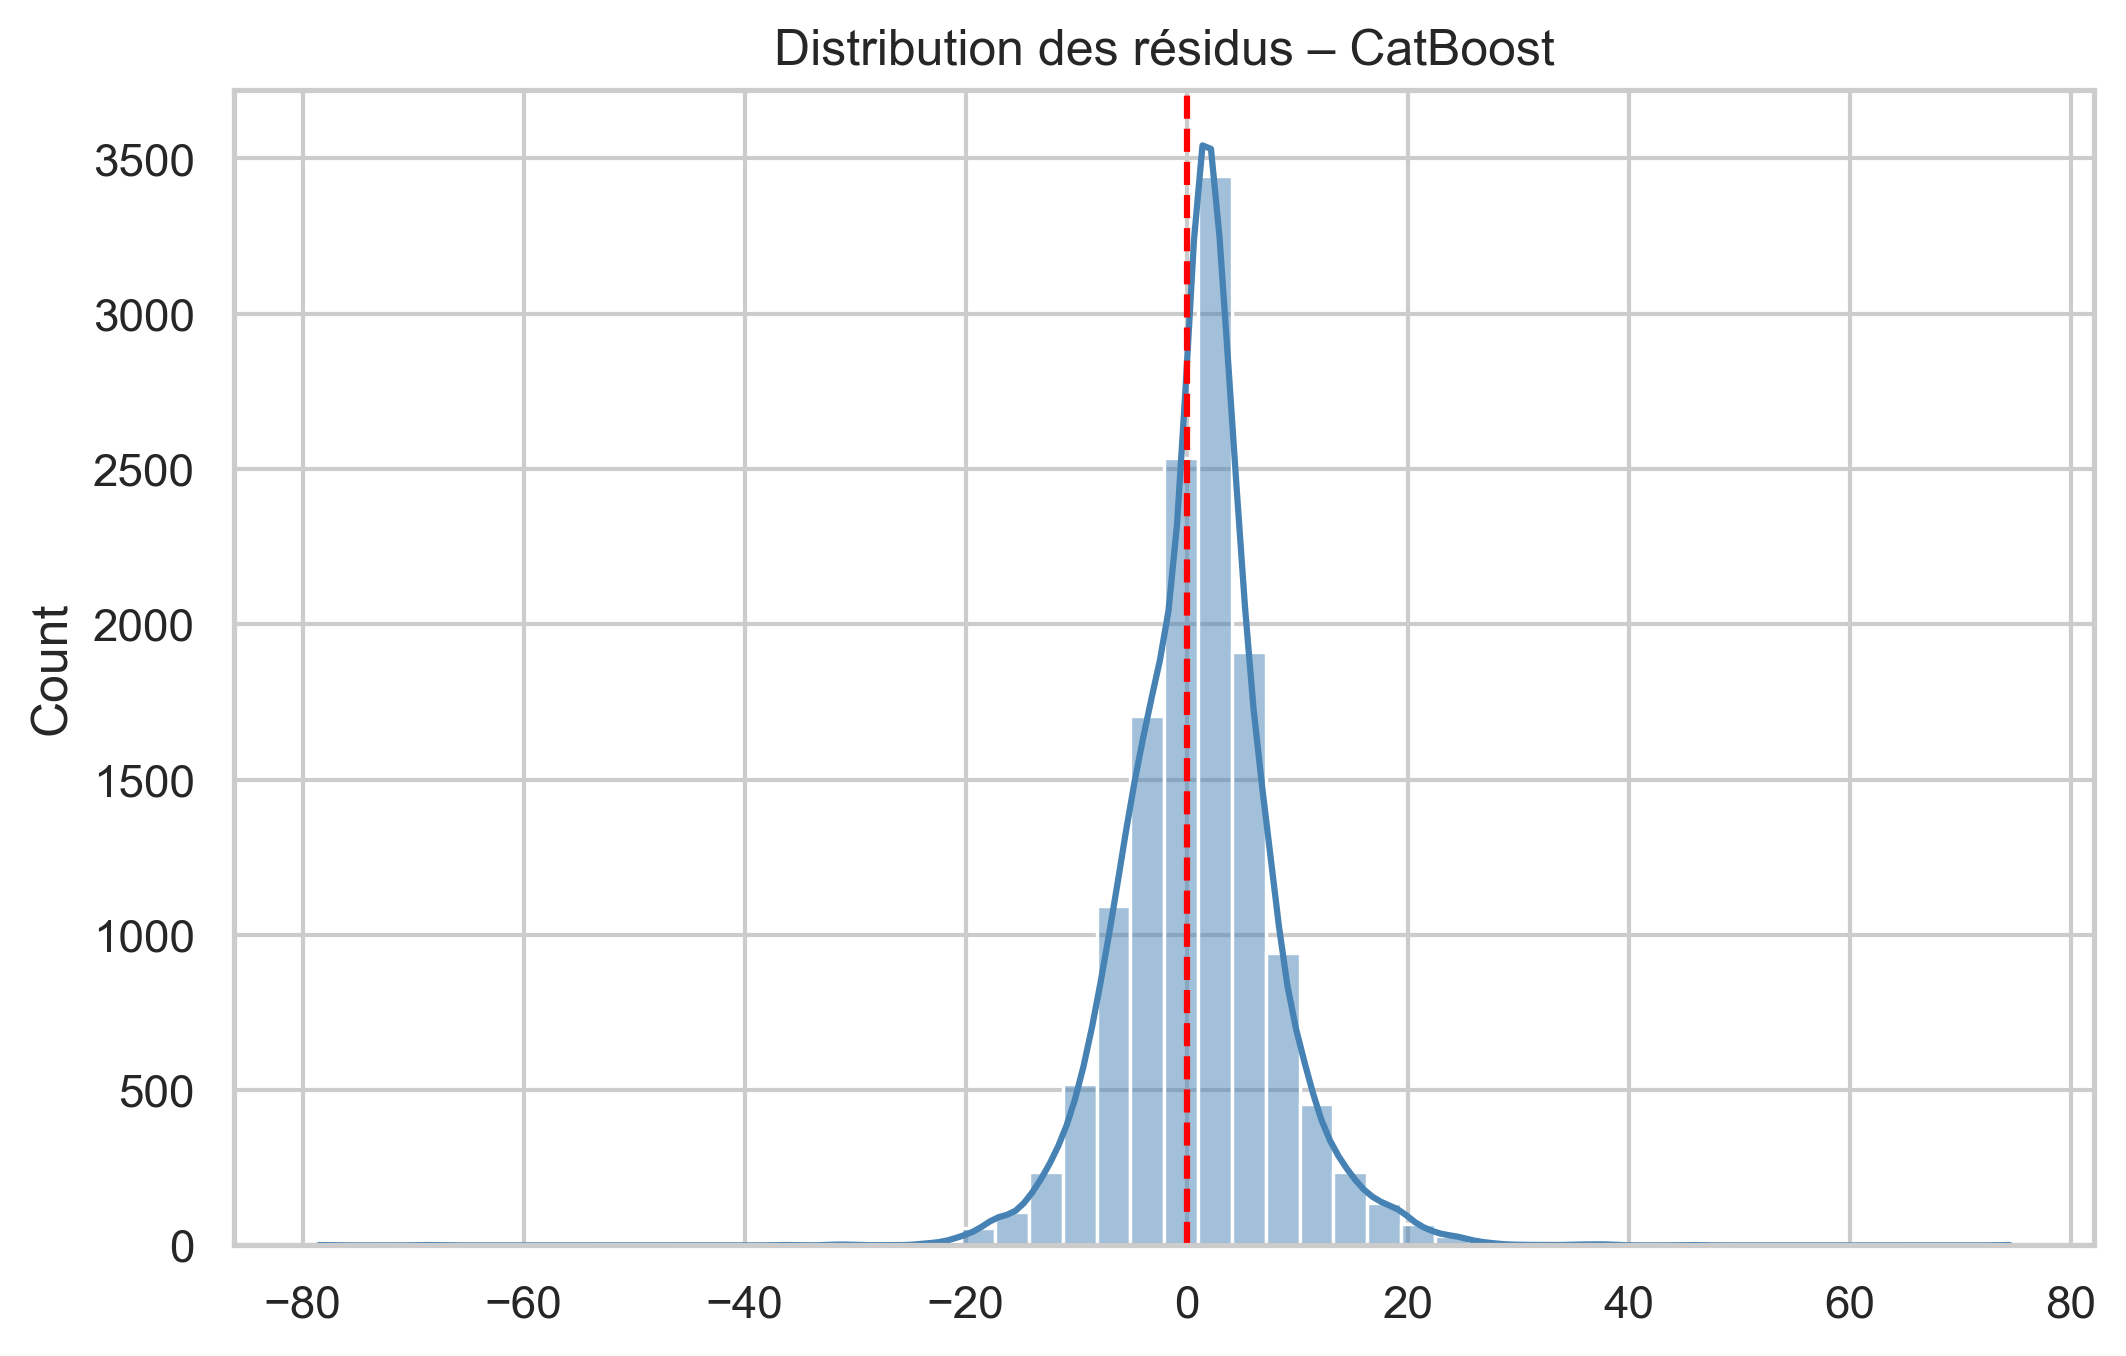

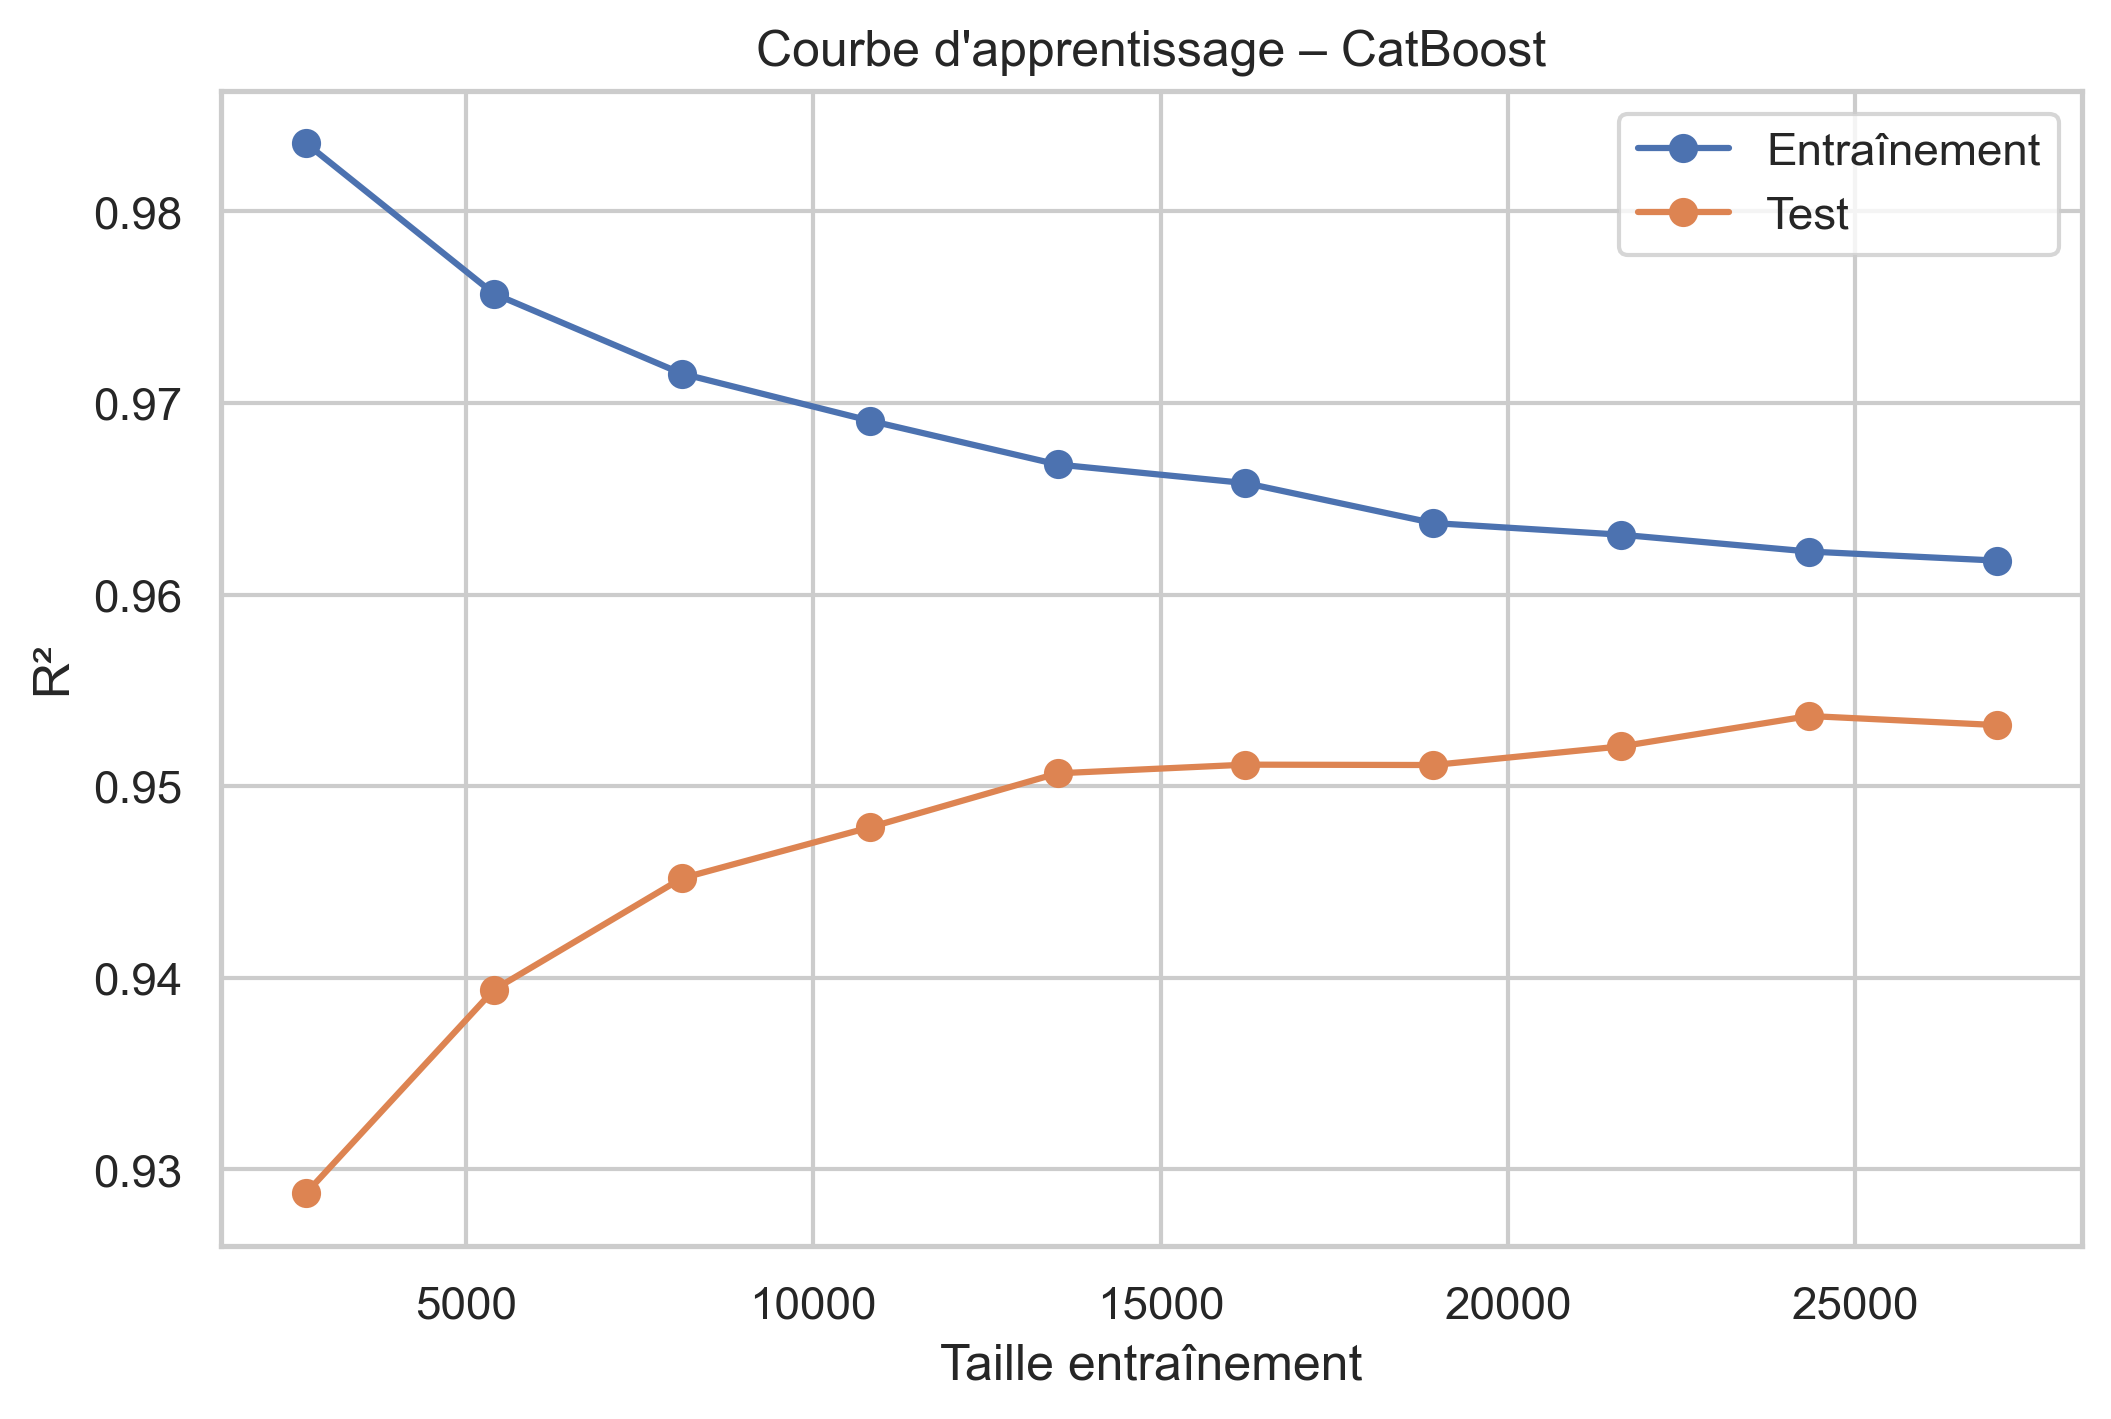

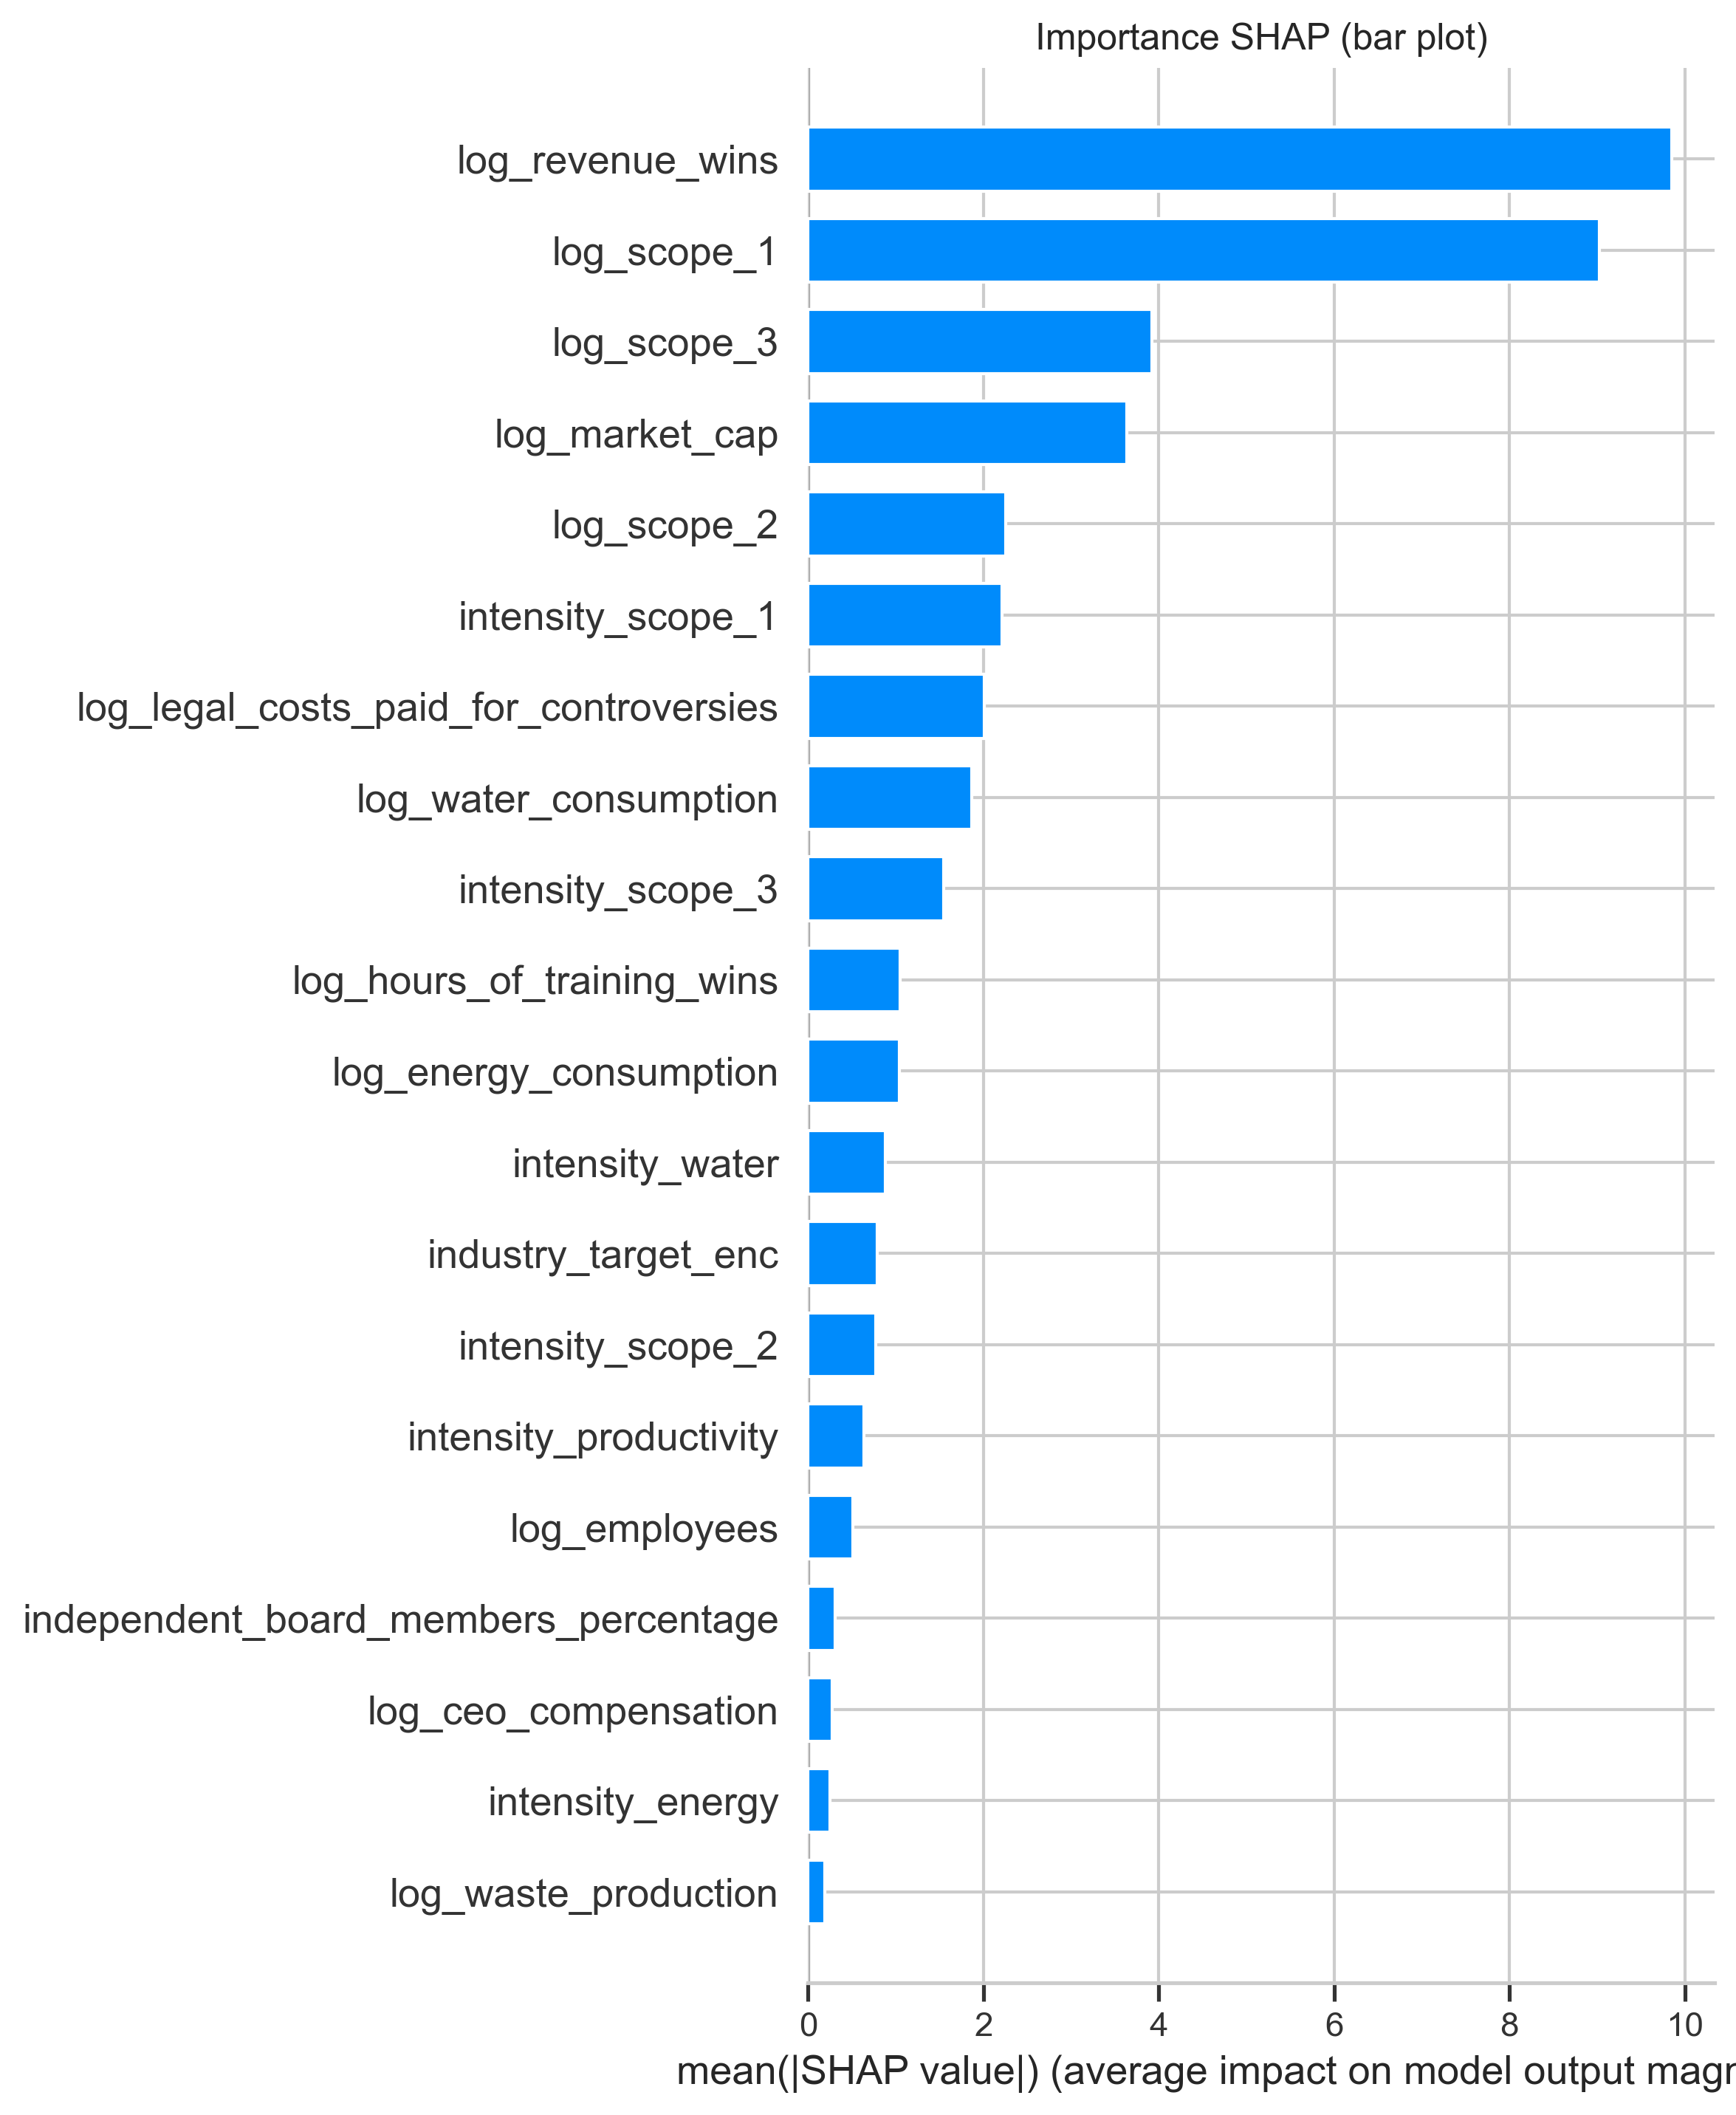

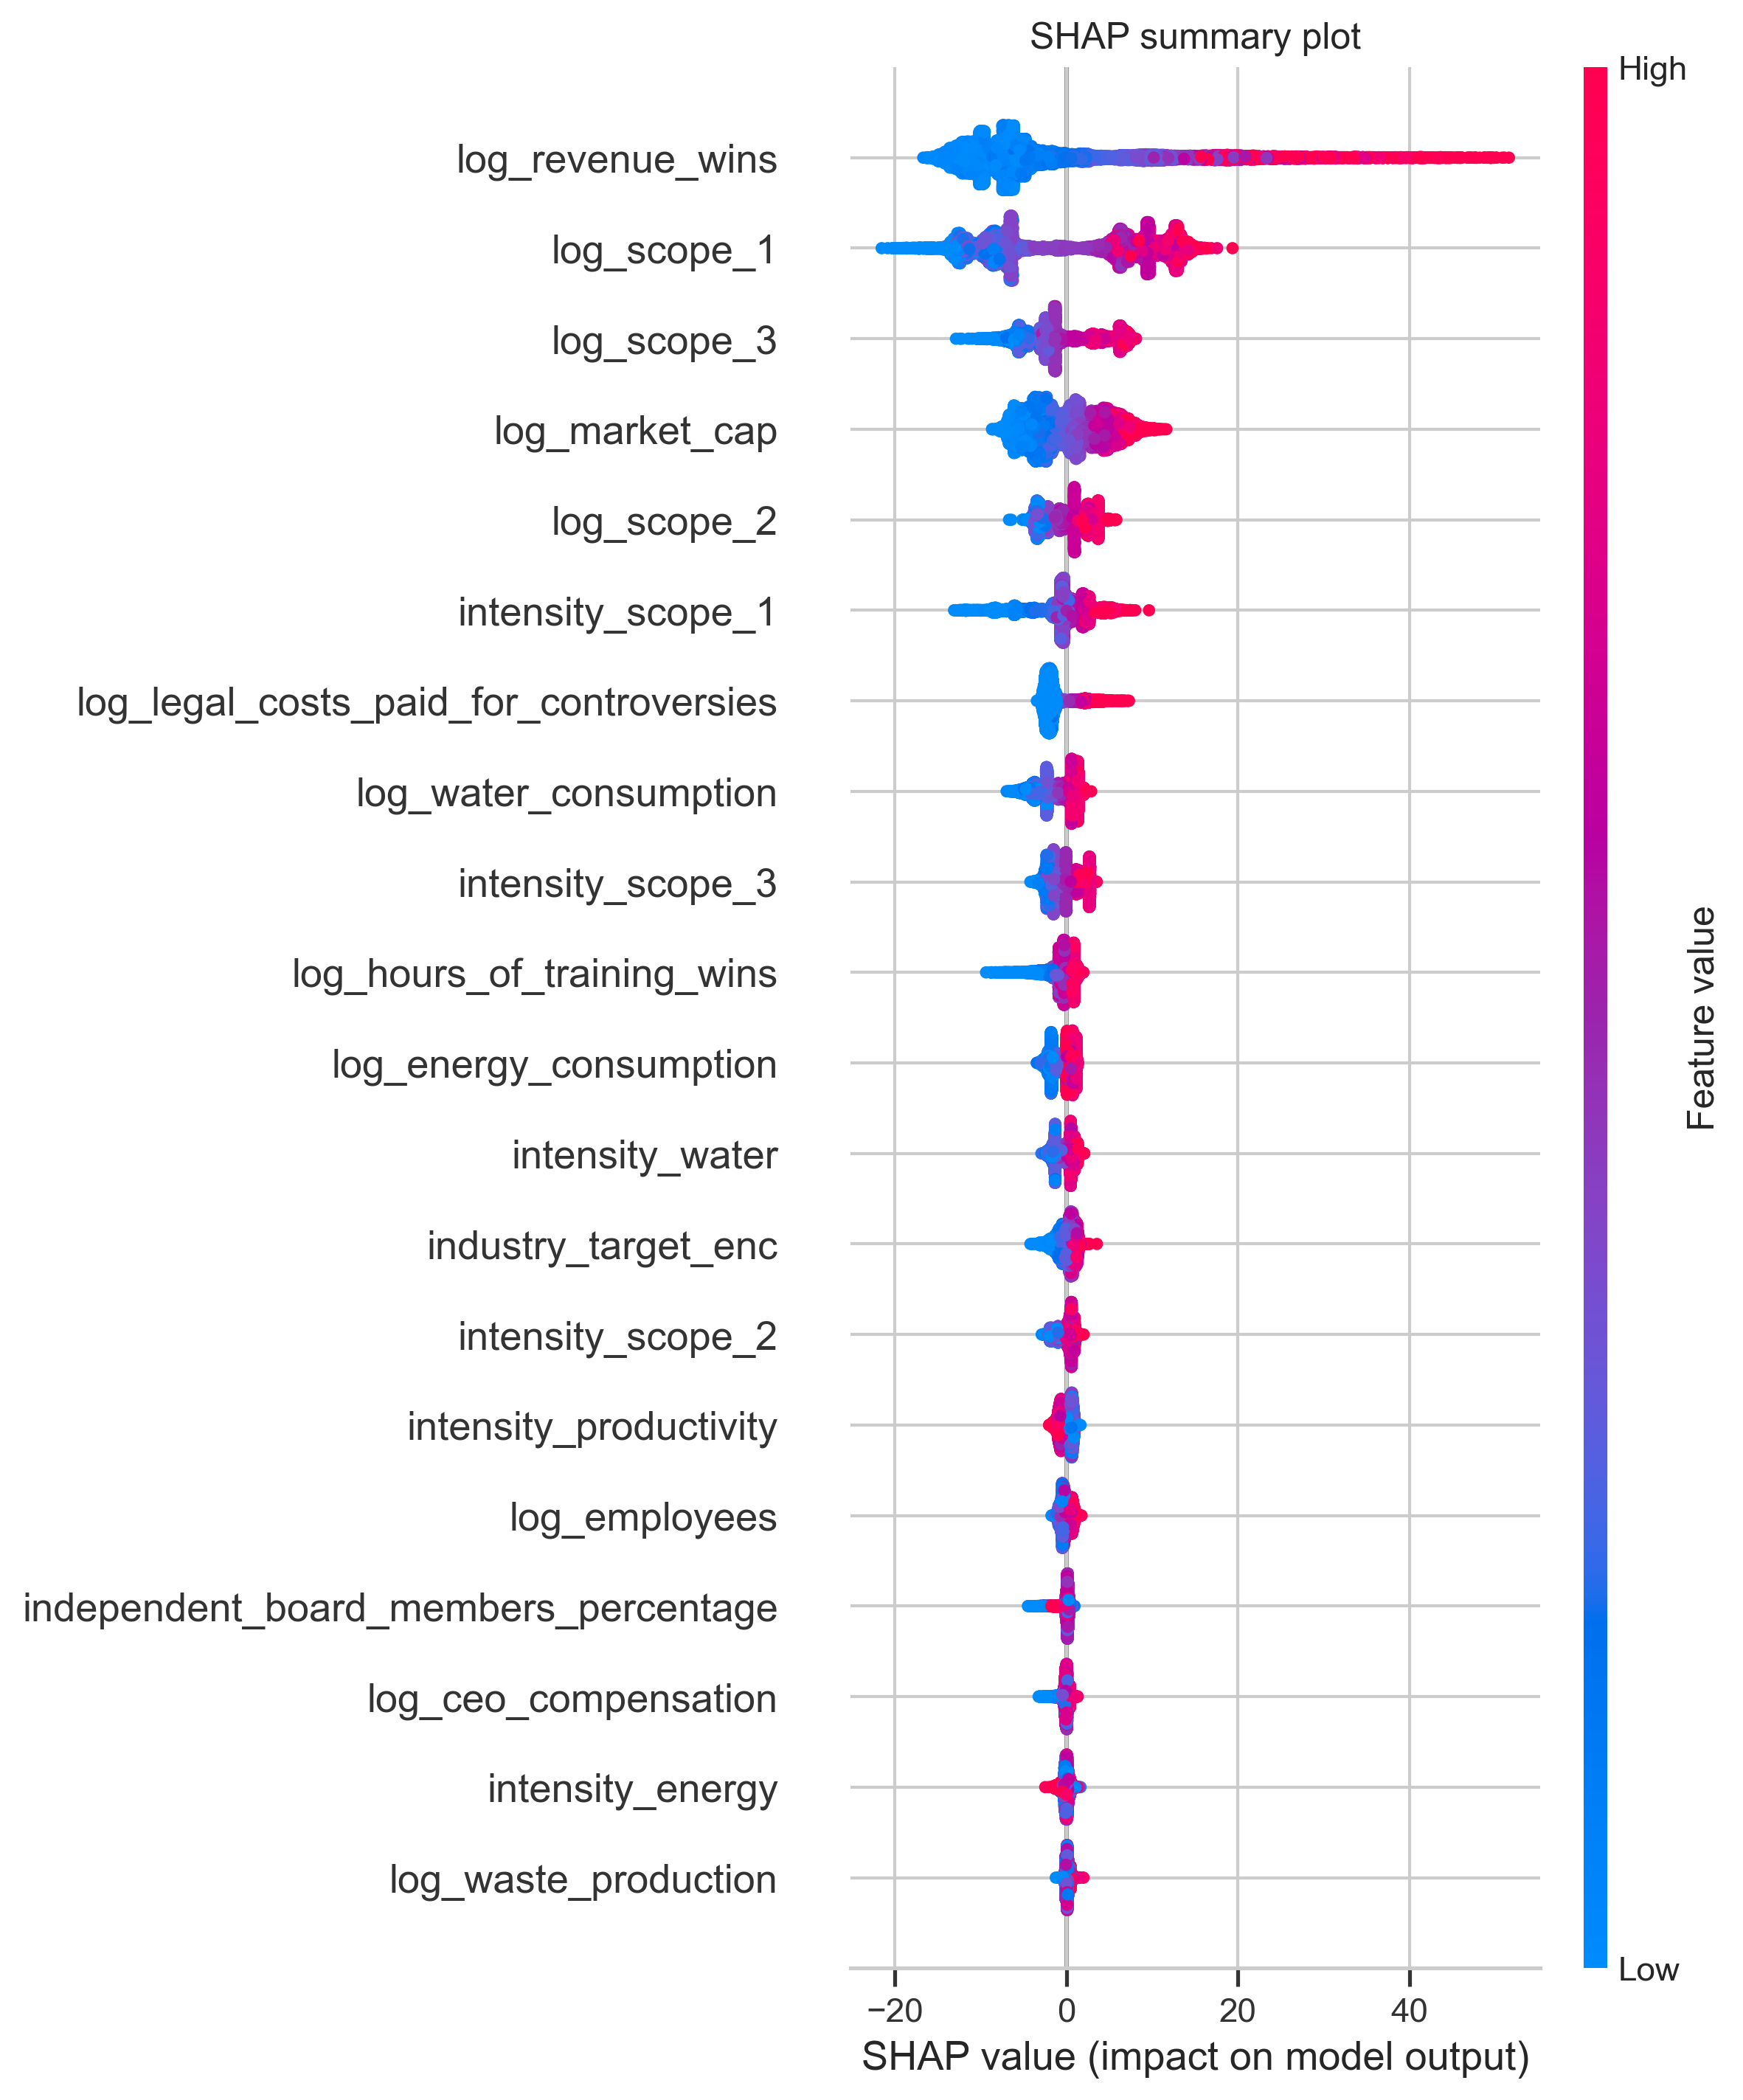

<Figure size 2400x1800 with 0 Axes>

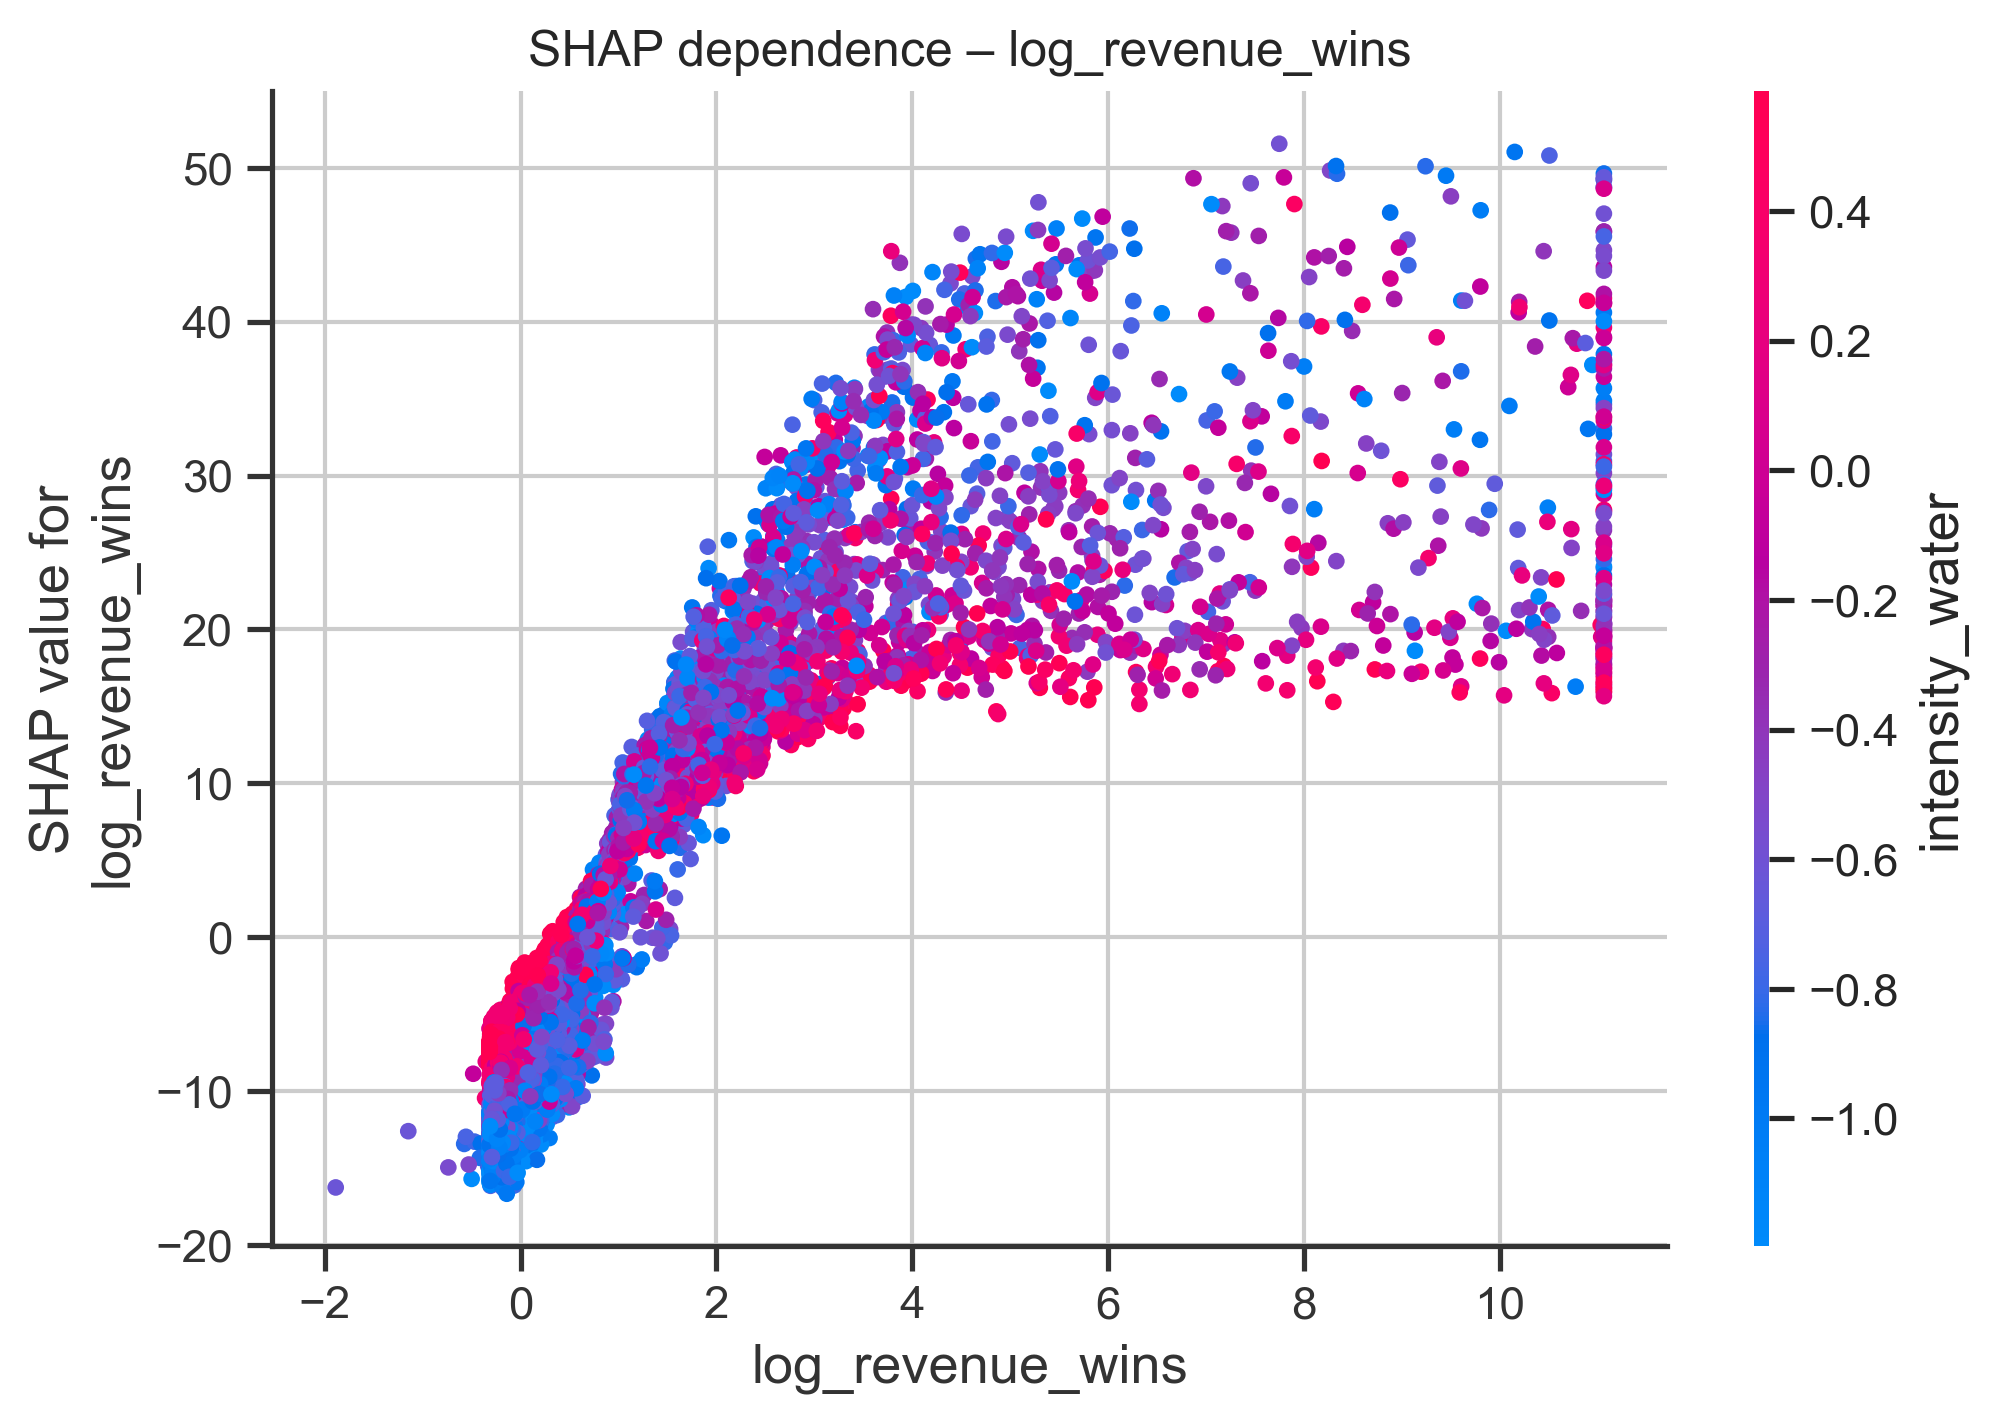

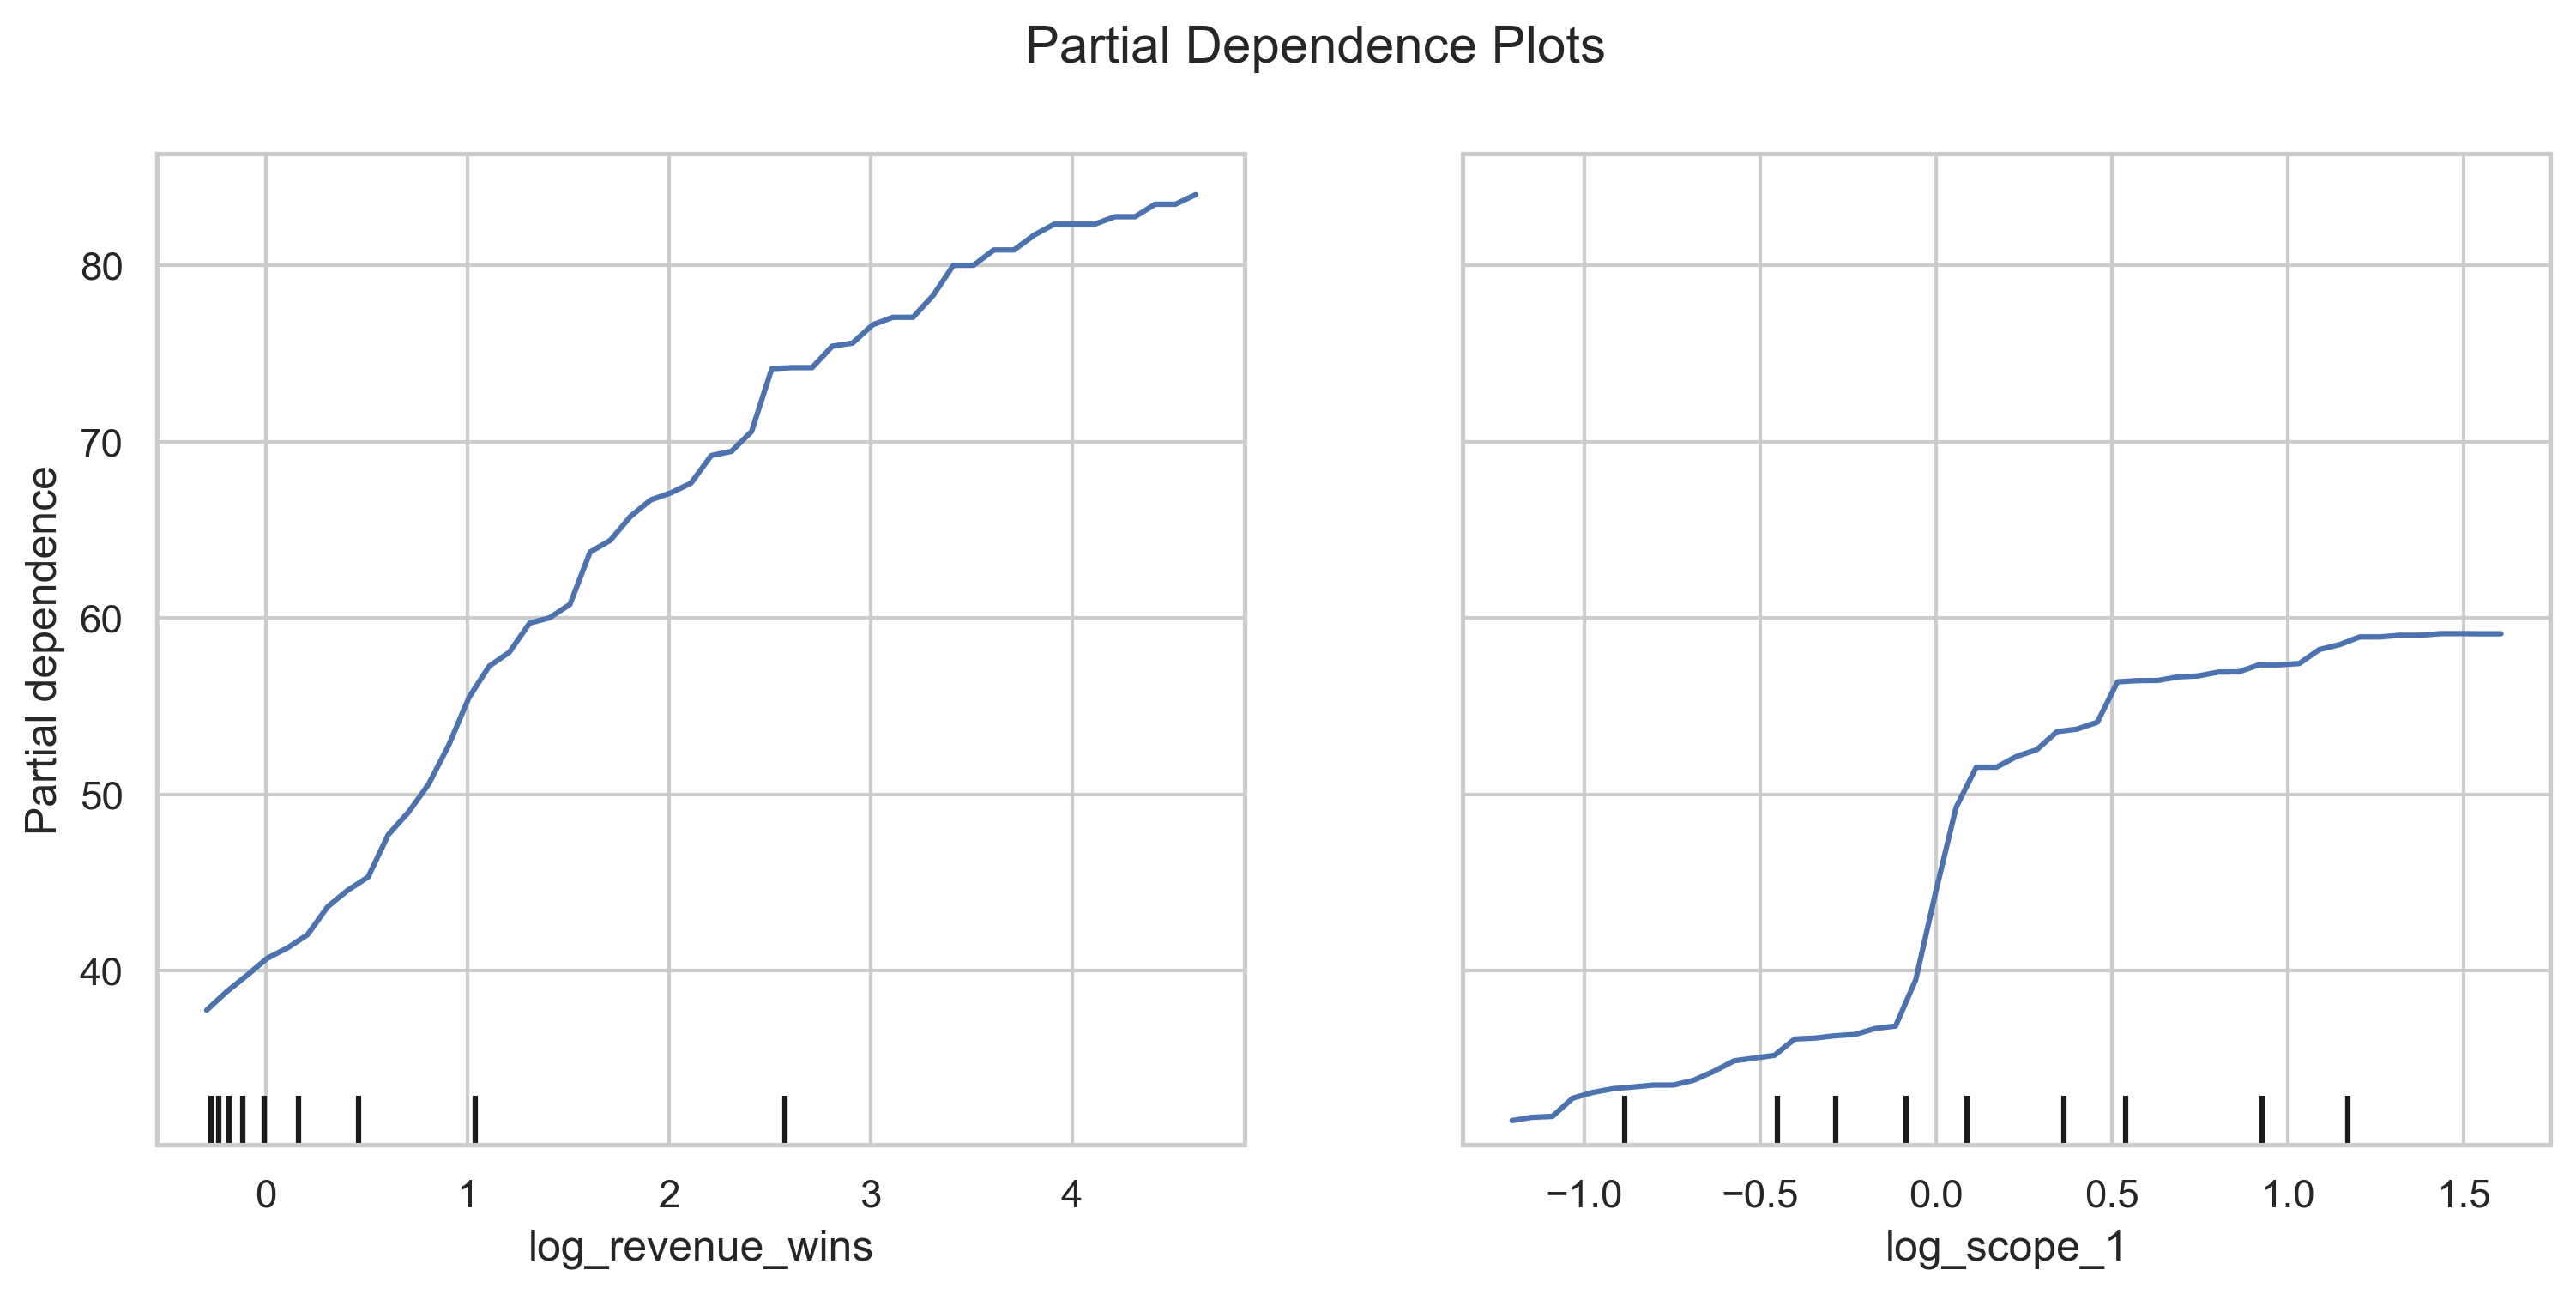


Tous les graphiques ont été sauvegardés dans le dossier 'figures/'.
Analyse terminée.


In [12]:
# =============================================================================
# 7. VISUALISATIONS (pour le meilleur modèle)
# =============================================================================
best_model_name = results_df.iloc[0]['Modèle']
best_model = models[best_model_name]
y_test_pred_best = predictions[best_model_name]

# Scatter + résidus
fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].scatter(y_test, y_test_pred_best, alpha=0.4, color='#2c3e50')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Réel'); axes[0].set_ylabel('Prédit'); axes[0].set_title(f'{best_model_name} : prédictions')
residuals = y_test - y_test_pred_best
axes[1].scatter(y_test_pred_best, residuals, alpha=0.4, color='#16a085')
axes[1].axhline(0, color='r', linestyle='--')
axes[1].set_xlabel('Prédit'); axes[1].set_ylabel('Résidus'); axes[1].set_title('Résidus')
plt.tight_layout()
plt.savefig("figures/scatter_residuals.png", dpi=300)
plt.show()

# QQ-plot
plt.figure(figsize=(6,6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title(f"QQ-plot des résidus – {best_model_name}")
plt.savefig("figures/qqplot_residuals.png", dpi=300)
plt.show()

# Histogramme des résidus
plt.figure(figsize=(8,5))
sns.histplot(residuals, bins=50, kde=True, color='steelblue')
plt.axvline(0, color='red', linestyle='--')
plt.title(f"Distribution des résidus – {best_model_name}")
plt.savefig("figures/histogram_residuals.png", dpi=300)
plt.show()

# Learning curve (pour XGBoost si c'est le meilleur, sinon générique)
train_sizes = np.linspace(0.1, 1.0, 10)
train_r2_scores, test_r2_scores = [], []
for frac in train_sizes:
    size = int(len(X_train) * frac)
    X_sub, y_sub = X_train[:size], y_train[:size]
    temp_model = best_model.__class__(**best_model.get_params())
    if best_model_name in ['XGBoost', 'LightGBM', 'CatBoost'] and hasattr(temp_model, 'set_params'):
        # désactiver early stopping temporairement
        if best_model_name == 'XGBoost':
            temp_model.set_params(early_stopping_rounds=None)
        elif best_model_name == 'LightGBM':
            temp_model.set_params(early_stopping_rounds=None)
        elif best_model_name == 'CatBoost':
            temp_model.set_params(early_stopping_rounds=None)
    temp_model.fit(X_sub, y_sub)
    train_r2_scores.append(r2_score(y_sub, temp_model.predict(X_sub)))
    test_r2_scores.append(r2_score(y_test, temp_model.predict(X_test)))
plt.figure(figsize=(8,5))
plt.plot(train_sizes * len(X_train), train_r2_scores, 'o-', label='Entraînement')
plt.plot(train_sizes * len(X_train), test_r2_scores, 'o-', label='Test')
plt.xlabel("Taille entraînement"); plt.ylabel("R²"); plt.title(f"Courbe d'apprentissage – {best_model_name}")
plt.legend()
plt.savefig("figures/learning_curve.png", dpi=300)
plt.show()

# SHAP (uniquement pour les modèles arborescents)
if best_model_name in ['XGBoost', 'RandomForest', 'LightGBM', 'CatBoost', 'DecisionTree']:
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test)
    plt.figure(figsize=(10,6))
    shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
    plt.title("Importance SHAP (bar plot)")
    plt.savefig("figures/shap_bar.png", dpi=300)
    plt.show()
    plt.figure(figsize=(10,6))
    shap.summary_plot(shap_values, X_test, show=False)
    plt.title("SHAP summary plot")
    plt.savefig("figures/shap_summary.png", dpi=300)
    plt.show()
    # Dependence plot pour la feature la plus importante
    imp = np.abs(shap_values).mean(0)
    top_idx = np.argmax(imp)
    top_feat = X_test.columns[top_idx]
    plt.figure(figsize=(8,6))
    shap.dependence_plot(top_idx, shap_values, X_test, show=False)
    plt.title(f"SHAP dependence – {top_feat}")
    plt.savefig("figures/shap_dependence.png", dpi=300)
    plt.show()

# PDP pour les deux features les plus importantes (basé sur l'importance SHAP)
if 'shap_values' in locals():
    from sklearn.inspection import PartialDependenceDisplay
    top_features = [X_test.columns[top_idx], X_test.columns[np.argsort(imp)[-2]]]
    fig, ax = plt.subplots(figsize=(12,5))
    PartialDependenceDisplay.from_estimator(best_model, X_test, top_features, ax=ax, grid_resolution=50)
    plt.suptitle("Partial Dependence Plots")
    plt.savefig("figures/pdp_plots.png", dpi=300)
    plt.show()

print("\nTous les graphiques ont été sauvegardés dans le dossier 'figures/'.")
print("Analyse terminée.")

In [10]:
# =============================================================================
# 8. INTERPRÉTATION FINALE
# =============================================================================
print("\n" + "="*80)
print("INTERPRÉTATION FINALE")
print("="*80)
print(f"Le meilleur modèle est {best_model_name} avec un R² test de {results_df.iloc[0]['R²_test']:.4f}.")
print(f"Son RMSE est de {results_df.iloc[0]['RMSE_test']:.2f} points, soit une erreur moyenne d'environ {results_df.iloc[0]['MAE_test']:.2f} points.")
print(f"L'overfitting (différence R²) est de {results_df.iloc[0]['Overfitting (R² diff)']:.4f}.")
if 'p_value' in locals():
    print(f"Test de comparaison avec le second modèle : p-value = {p_value:.6f}")
print("\nTous les graphiques ont été sauvegardés dans le dossier 'figures/'.")
print("Les métriques avec intervalles de confiance (bootstrap) sont disponibles dans le tableau.")



INTERPRÉTATION FINALE
Le meilleur modèle est CatBoost avec un R² test de 0.9532.
Son RMSE est de 6.65 points, soit une erreur moyenne d'environ 4.95 points.
L'overfitting (différence R²) est de 0.0086.
Test de comparaison avec le second modèle : p-value = 0.000002

Tous les graphiques ont été sauvegardés dans le dossier 'figures/'.
Les métriques avec intervalles de confiance (bootstrap) sont disponibles dans le tableau.


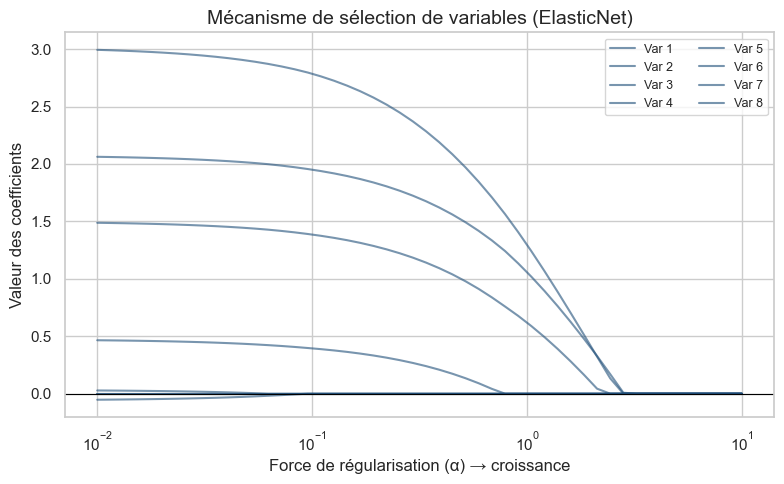

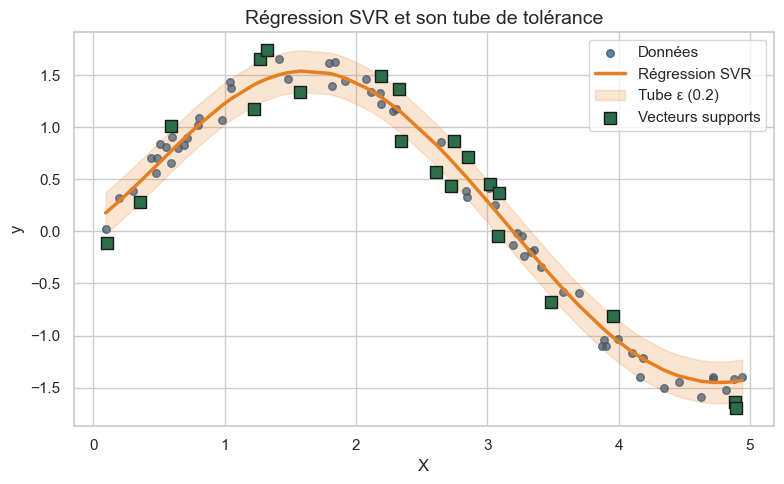

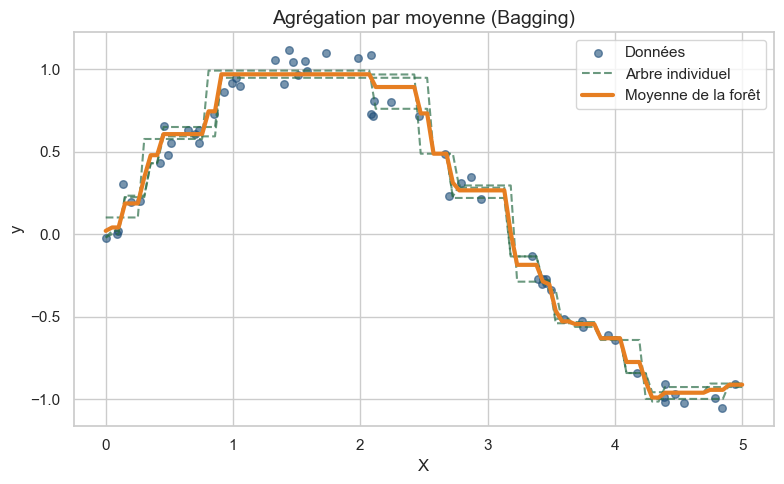

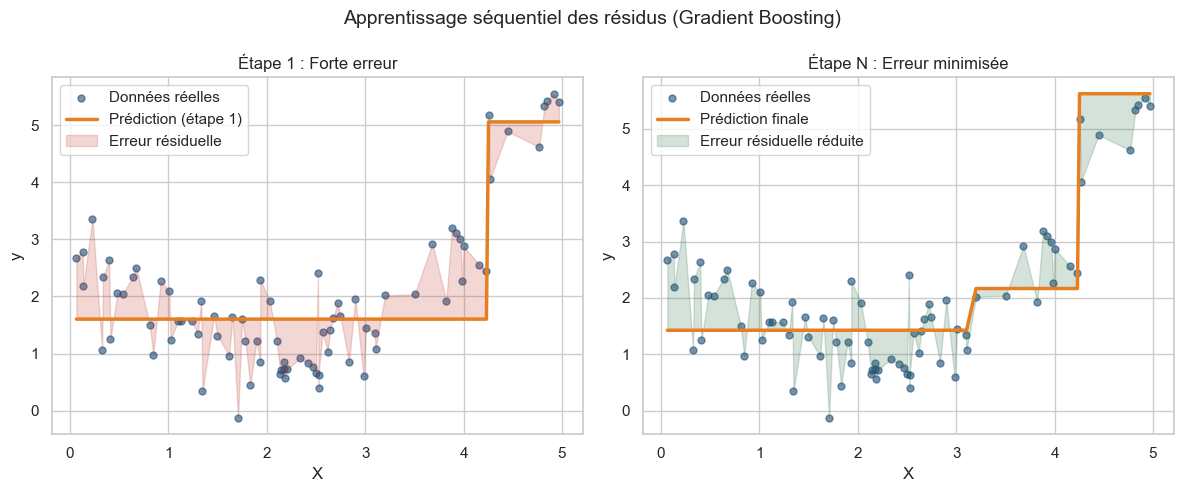

Tous les graphiques ont été générés avec succès.


In [5]:
colors = {
    "blue": "#1f4e79",
    "green": "#2c6e49",
    "orange": "#e67e22",
    "red": "#c0392b"      # rouge brique professionnel
}

# ----------------------------------------------------------------------
# Figure 5.1 : ElasticNet – Mécanisme de sélection de variables
# ----------------------------------------------------------------------
np.random.seed(42)
n_features = 8
alphas = np.logspace(-2, 1, 50)
coeffs = []

X_synthetic = np.random.randn(100, n_features)
y_synthetic = 3 * X_synthetic[:, 0] + 2 * X_synthetic[:, 1] + 1.5 * X_synthetic[:, 2] + 0.5 * X_synthetic[:, 3] + np.random.randn(100) * 0.5

for alpha in alphas:
    enet = ElasticNet(alpha=alpha, l1_ratio=0.7, random_state=42)
    enet.fit(X_synthetic, y_synthetic)
    coeffs.append(enet.coef_)

coeffs = np.array(coeffs)

plt.figure(figsize=(8, 5))
for i in range(n_features):
    plt.plot(alphas, coeffs[:, i], label=f'Var {i+1}', color=colors["blue"], alpha=0.6, linewidth=1.5)
plt.xscale('log')
plt.xlabel('Force de régularisation (α) → croissance', fontsize=12)
plt.ylabel('Valeur des coefficients', fontsize=12)
plt.title('Mécanisme de sélection de variables (ElasticNet)', fontsize=14)
plt.axhline(0, color='black', linestyle='-', linewidth=0.8)
plt.legend(loc='upper right', ncol=2, fontsize=9)
plt.tight_layout()
plt.savefig('figure_5.1_elasticnet.png', dpi=300)
plt.show()

# ----------------------------------------------------------------------
# Figure 5.2 : SVR – Tube d'insensibilité epsilon et vecteurs supports
# ----------------------------------------------------------------------
np.random.seed(0)
X_svr = np.sort(5 * np.random.rand(80, 1), axis=0)
y_svr = np.sin(X_svr).ravel() + np.random.randn(80) * 0.1
y_svr = y_svr * 1.5

svr = SVR(kernel='rbf', C=1.0, epsilon=0.2)
svr.fit(X_svr, y_svr)
y_pred = svr.predict(X_svr)
epsilon = svr.epsilon

support_vectors = svr.support_vectors_
support_idx = [np.where(X_svr == sv)[0][0] for sv in support_vectors if np.any(X_svr == sv)]

plt.figure(figsize=(8, 5))
plt.scatter(X_svr, y_svr, color=colors["blue"], s=30, label='Données', alpha=0.7)
plt.plot(X_svr, y_pred, color=colors["orange"], linewidth=2.5, label='Régression SVR')
plt.fill_between(X_svr.ravel(), y_pred - epsilon, y_pred + epsilon, color=colors["orange"], alpha=0.2, label='Tube ε (0.2)')
plt.scatter(X_svr[support_idx], y_svr[support_idx], color=colors["green"], s=80, marker='s', edgecolors='k', linewidth=1, label='Vecteurs supports')
plt.xlabel('X', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Régression SVR et son tube de tolérance', fontsize=14)
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('figure_5.2_svr.png', dpi=300)
plt.show()

# ----------------------------------------------------------------------
# Figure 5.3 : Random Forest – Agrégation par moyenne (Bagging)
# ----------------------------------------------------------------------
np.random.seed(1)
X_rf = np.sort(5 * np.random.rand(60, 1), axis=0)
y_rf = np.sin(X_rf).ravel() + np.random.randn(60) * 0.1

trees = []
for _ in range(3):
    idx = np.random.choice(len(X_rf), len(X_rf), replace=True)
    X_boot, y_boot = X_rf[idx], y_rf[idx]
    tree = DecisionTreeRegressor(max_depth=4, random_state=None)
    tree.fit(X_boot, y_boot)
    trees.append(tree)

X_test = np.linspace(0, 5, 100).reshape(-1, 1)
preds = np.array([tree.predict(X_test) for tree in trees])
mean_pred = np.mean(preds, axis=0)

plt.figure(figsize=(8, 5))
plt.scatter(X_rf, y_rf, color=colors["blue"], s=30, alpha=0.6, label='Données')
for i, pred in enumerate(preds):
    plt.plot(X_test, pred, linestyle='--', linewidth=1.5, alpha=0.7, color=colors["green"], label='Arbre individuel' if i == 0 else "")
plt.plot(X_test, mean_pred, color=colors["orange"], linewidth=3, label='Moyenne de la forêt')
plt.xlabel('X', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Agrégation par moyenne (Bagging)', fontsize=14)
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('figure_5.3_random_forest.png', dpi=300)
plt.show()

# ----------------------------------------------------------------------
# Figure 5.4 : Gradient Boosting – Apprentissage séquentiel des résidus
# ----------------------------------------------------------------------
np.random.seed(2)
X_gb = np.sort(5 * np.random.rand(80, 1), axis=0)
y_gb = 0.5 * X_gb.ravel()**2 - 2 * X_gb.ravel() + 3 + np.random.randn(80) * 0.5

model1 = DecisionTreeRegressor(max_depth=1)
model1.fit(X_gb, y_gb)
pred1 = model1.predict(X_gb)

residuals = y_gb - pred1

model2 = DecisionTreeRegressor(max_depth=1)
model2.fit(X_gb, residuals)
pred2 = model2.predict(X_gb)

y_final = pred1 + pred2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.scatter(X_gb, y_gb, color=colors["blue"], s=25, alpha=0.6, label='Données réelles')
ax1.plot(X_gb, pred1, color=colors["orange"], linewidth=2.5, label='Prédiction (étape 1)')
ax1.fill_between(X_gb.ravel(), y_gb, pred1, color=colors["red"], alpha=0.2, label='Erreur résiduelle')
ax1.set_xlabel('X', fontsize=12)
ax1.set_ylabel('y', fontsize=12)
ax1.set_title('Étape 1 : Forte erreur', fontsize=12)
ax1.legend(loc='upper left')

ax2.scatter(X_gb, y_gb, color=colors["blue"], s=25, alpha=0.6, label='Données réelles')
ax2.plot(X_gb, y_final, color=colors["orange"], linewidth=2.5, label='Prédiction finale')
ax2.fill_between(X_gb.ravel(), y_gb, y_final, color=colors["green"], alpha=0.2, label='Erreur résiduelle réduite')
ax2.set_xlabel('X', fontsize=12)
ax2.set_ylabel('y', fontsize=12)
ax2.set_title('Étape N : Erreur minimisée', fontsize=12)
ax2.legend(loc='upper left')

fig.suptitle('Apprentissage séquentiel des résidus (Gradient Boosting)', fontsize=14)
plt.tight_layout()
plt.savefig('figure_5.4_gradient_boosting.png', dpi=300)
plt.show()

print("Tous les graphiques ont été générés avec succès.")